<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project2/pafolabi_DIAML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data, Inference, and Applied Machine Learning**: Project Assignment II

In [76]:
#Imports all neccessary Python libraries
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

##Question 1
**Data source**: [World Bank Indicators](https://data.worldbank.org/indicator)

###a. Before looking at the data, state what kind of relationship you expect.
Before looking at the data of **GDP per capita (current
US$)** and **Prevalence of underweight, weight for age
(% of children under 5)**, I expect to see the following relationship:
1. As the world GDP increases (the GDP of countries), I expect that the percentage of underweight children decreases, yielding an inverse relationship between world GDP and percentage of underweight children.
2. The cumulative world GDP over several years.
3. The amount, either in percentage or in realised value, various countries contributed to the world GDP growth in an accounting year.
4. The percentage of underweight children in the world over a good number of years.
---
###b. Clean the data and say what you removed and why. Report how many years of observations and how many distinct countries you are left with.

In [77]:
# Data ingestion and cleaning

# 1. World GDP Data Ingestion
world_gdp_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
                           skiprows=4)
world_gdp_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')
world_gdp_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Indicator_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')


# 2. World Percentage of Underage Children Data Ingestion
world_pcnt_underwgth_chld_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv',
    skiprows=4)
world_pcnt_underwgth_chld_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Country_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')
world_pcnt_underwgth_chld_metadata_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Indicator_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')

# 3. Exploration of DFs
#world_gdp_df.head()
#world_gdp_metadata_country_df.head()
#world_gdp_indicator_df.head()

#world_pcnt_underwgth_chld_df.count()
#world_pcnt_underwgth_chld_metadata_country_df.tail()
#world_pcnt_underwgth_chld_metadata_indicator_df.head()

# 4. Data cleaning operations
region_notna = world_gdp_metadata_country_df['Region'].notna()
country_codes = world_gdp_metadata_country_df[region_notna]['Country Code']
clean_world_gdp_df = world_gdp_df[world_gdp_df['Country Code'].isin(country_codes)]
clean_world_underweight_df = world_pcnt_underwgth_chld_df[world_pcnt_underwgth_chld_df['Country Code'].isin(country_codes)]

world_gdp_long_df = clean_world_gdp_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_gdp_df.columns],
    var_name='Year',
    value_name='GDP_per_capita'
)

world_pcnt_underwight_long_df = clean_world_underweight_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_underweight_df.columns],
    var_name='Year',
    value_name='Percentage_Underweight'
)

merged_df = pd.merge(
    world_gdp_long_df,
    world_pcnt_underwight_long_df,
    on=['Country Code', 'Country Name','Year'],
    how='inner'
)

final_df = merged_df.dropna(subset=['GDP_per_capita', 'Percentage_Underweight'])
final_df['Year'] = final_df['Year'].astype(int)


/tmp/ipykernel_1004/787208523.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Year'] = final_df['Year'].astype(int)


### Explanation of Data Cleaning

1.  **Filtering by Region**: Initially, both the World GDP and Underweight Children datasets contained aggregate entities (e.g., 'World', 'European Union') which are not individual countries. These were removed by filtering for 'Country Code' values that corresponded to entries with a non-null 'Region' in the `world_gdp_metadata_country_df`. This ensures that only actual country data is considered.
2.  **Melting DataFrames**: The raw data was in a wide format, with each year as a separate column. I transformed both datasets into a 'long' format using `melt()`. This reshaped the data so that each row represents a unique combination of country and year, with separate columns for 'Year', 'Country Name', 'Country Code', and the respective indicator values ('GDP_per_capita' or 'Percentage_Underweight'). This is essential for easier merging and time-series analysis.
3.  **Merging DataFrames**: The GDP per capita and Percentage Underweight data were merged into a single DataFrame (`merged_df`) using 'Country Code', 'Country Name', and 'Year' as common keys. An 'inner' merge was used, meaning only rows that have matching values in all key columns in both DataFrames were kept. This ensures we only have data points where both indicators are available for a given country and year.
4.  **Handling Missing Values**: Finally, rows where either 'GDP_per_capita' or 'Percentage_Underweight' had missing values (NaN) were dropped using `dropna()`. This step ensures that our analysis only uses complete data points, preventing skewing from incomplete observations.
5.  **Data Type Conversion**: The 'Year' column was converted to an integer type for consistency and easier numerical operations.


In [78]:
num_years = final_df['Year'].nunique()
num_countries = final_df['Country Name'].nunique()

print(f"Number of years of observations: {num_years}")
print(f"Number of distinct countries: {num_countries}")

Number of years of observations: 42
Number of distinct countries: 161


### c. Make a scatter plot of malnutrition prevalence against GDP per capita, using all available years and countries. What kind of relationship do you see, and how does it compare with your hypothesis? Then redraw the same plot with GDP per capita on a logarithmic axis, and say which of the two you would publish.

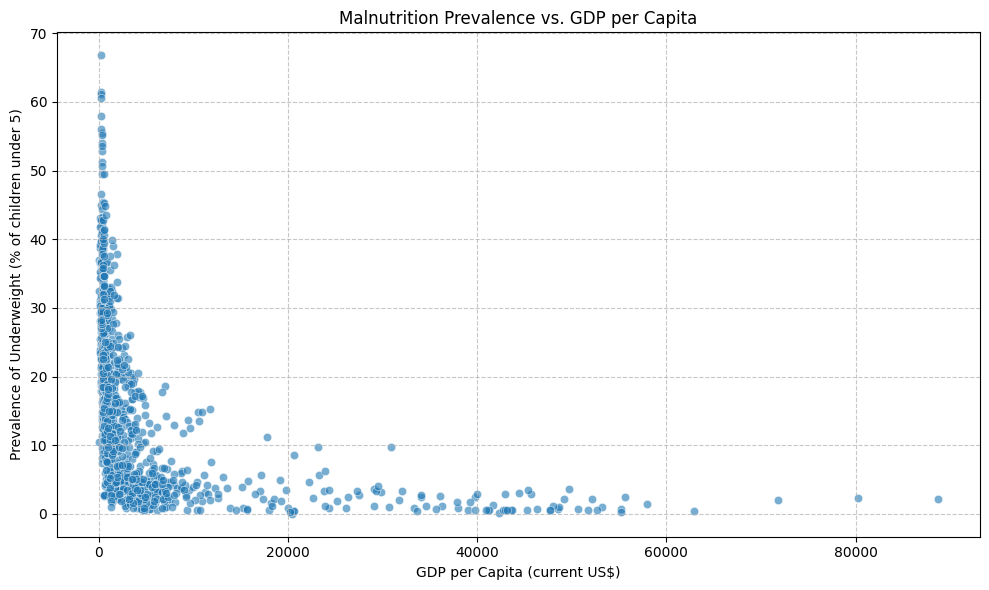

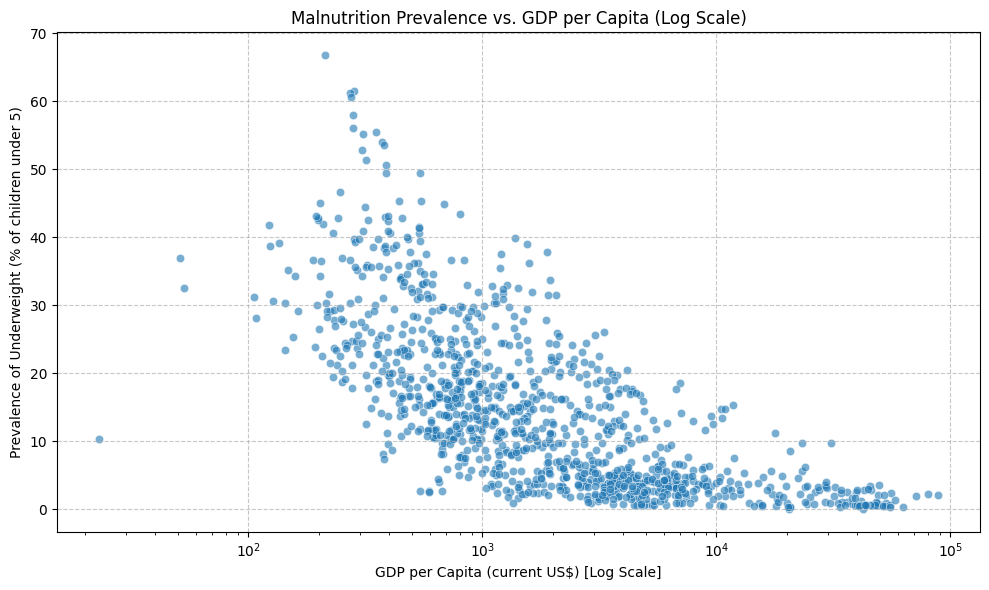

In [79]:
# Scatter plot of malnutrition prevalence against GDP per capita
fig1 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.title('Malnutrition Prevalence vs. GDP per Capita')
plt.xlabel('GDP per Capita (current US$)')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot with GDP per capita on a logarithmic axis
fig2 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale)')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.c)

**Relationship Observed (Linear Scale)**:

In the first scatter plot (linear scale), we can observe a general trend where as GDP per capita increases, the prevalence of underweight children tends to decrease. This aligns with the initial hypothesis of an inverse relationship. However, the data points are heavily clustered towards the lower end of the GDP per capita scale, making it difficult to discern patterns among countries with lower GDP and to fully appreciate the relationship across the entire range.

**Relationship Observed (Logarithmic Scale)**:

The second scatter plot, with GDP per capita on a logarithmic axis, provides a much clearer view of the relationship. The logarithmic scale compresses the higher GDP values and expands the lower GDP values, spreading out the clustered points and revealing more detail. In this plot, the inverse relationship is more evident and appears more consistent across different income levels. The distribution of data points is more uniform, allowing for better identification of trends and outliers.

**Which plot to publish?**:

I would publish the **scatter plot with GDP per capita on a logarithmic axis**. This is because:

*   **Better Visualization of Skewed Data**: Economic data like GDP per capita often has a heavily skewed distribution, with a few high-income countries and many low-to-middle-income countries. A logarithmic scale effectively handles this skewness, making the distribution of data points more interpretable.
*   **Clearer Trend Identification**: The inverse relationship between GDP per capita and malnutrition prevalence is much more clearly and evenly depicted across the range of GDP values on a logarithmic scale. It allows us to observe nuances in the relationship that are obscured on a linear scale.
*   **Enhanced Detail for Lower GDP Countries**: The logarithmic scale provides more visual emphasis on the differences among lower GDP countries, which are often the most relevant for studying malnutrition.


### d. Make a scatter plot coloured by geographical region and another coloured by income level. Which of the two plots is more informative?

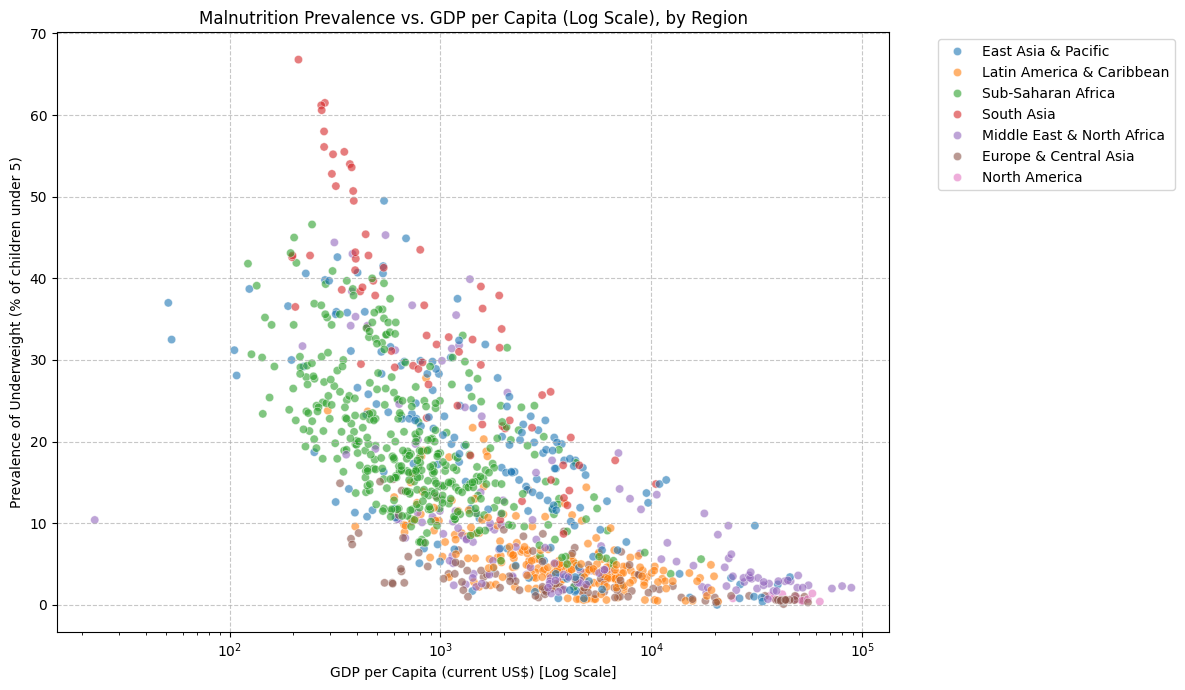

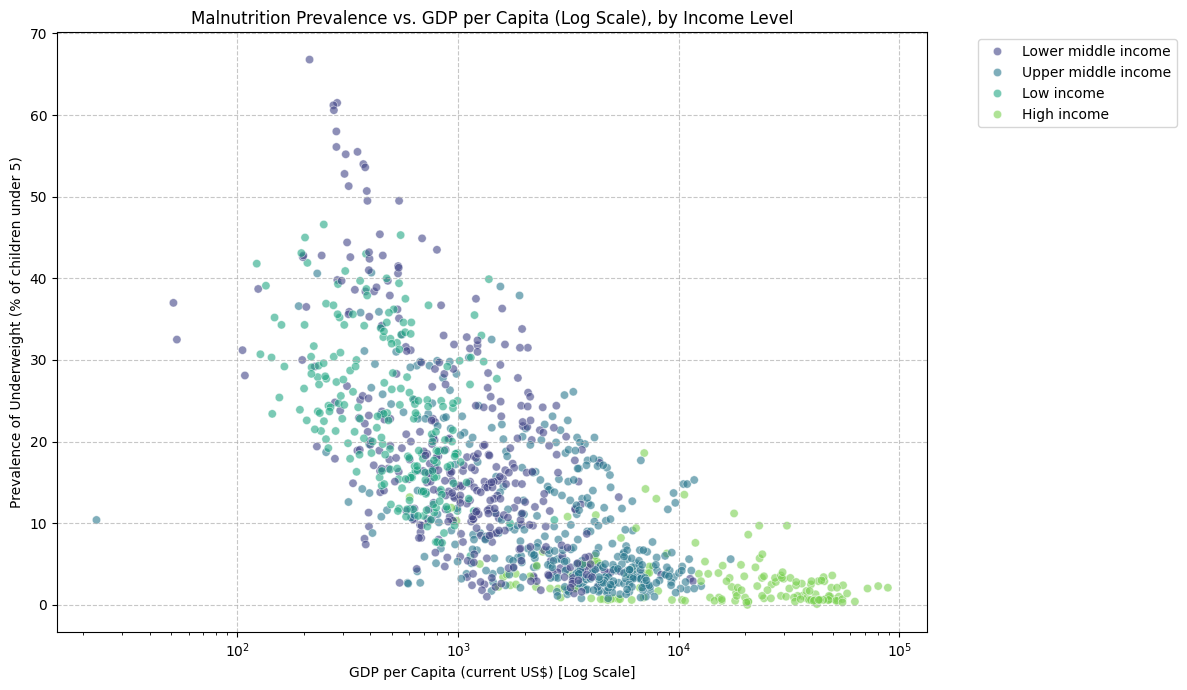

In [80]:
metadata_df = world_gdp_metadata_country_df[['Country Code', 'Region', 'IncomeGroup']].copy()
final_df_with_metadata = pd.merge(final_df, metadata_df, on='Country Code', how='left')

# Scatter plot colored by Geographical Region
fig3 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='Region', alpha=0.6, palette='tab10')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Region')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter plot colored by Income Level
fig4 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='IncomeGroup', alpha=0.6, palette='viridis')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Income Level')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.d)

**Which plot is more informative?**

Both plots offer valuable insights, but the **scatter plot colored by Income Level is generally more informative** for understanding the relationship between GDP per capita and malnutrition prevalence.

Here's why:

*   **Direct Correlation with GDP**: Income Group is directly defined by GDP per capita. Therefore, coloring by income level inherently reinforces and clarifies the underlying trend. We can clearly see how countries transition from 'Low income' (typically higher malnutrition, lower GDP) through 'Lower middle income', 'Upper middle income', to 'High income' (typically lower malnutrition, higher GDP), creating a more structured and coherent visual progression.

*   **Clearer Segregation of Trends**: The income level categories tend to group countries with similar economic development and, consequently, similar levels of malnutrition and GDP. This provides a more distinct and understandable segmentation of the data, allowing us to easily identify clusters and patterns within each income group.

*   **Actionable Insights**: From a policy perspective, understanding the relationship within specific income groups can be more actionable. Interventions for malnutrition might differ significantly between a 'Low income' country and a 'High income' country, even if both are in the same geographical region.

**Comparison with Geographical Region Plot**:

The plot colored by geographical region is also useful, as it shows regional disparities. For example, countries in 'Sub-Saharan Africa' might consistently appear at the lower end of the GDP scale with higher malnutrition. However, geographical regions are more diverse in terms of economic development. A single region might contain countries with vastly different GDPs and malnutrition rates, leading to more overlapping and less clear-cut distinctions between the colored groups compared to income levels. While it highlights regional clusters, it doesn't explain the *why* of the GDP-malnutrition relationship as effectively as income groups do.

In conclusion, while both plots offer different perspectives, the **Income Level plot provides a more direct and interpretable visual explanation of the relationship between a country's economic standing (proxied by GDP) and its child malnutrition rates.**

### e. Plot the number of observations per year. What do you observe about reporting frequency?

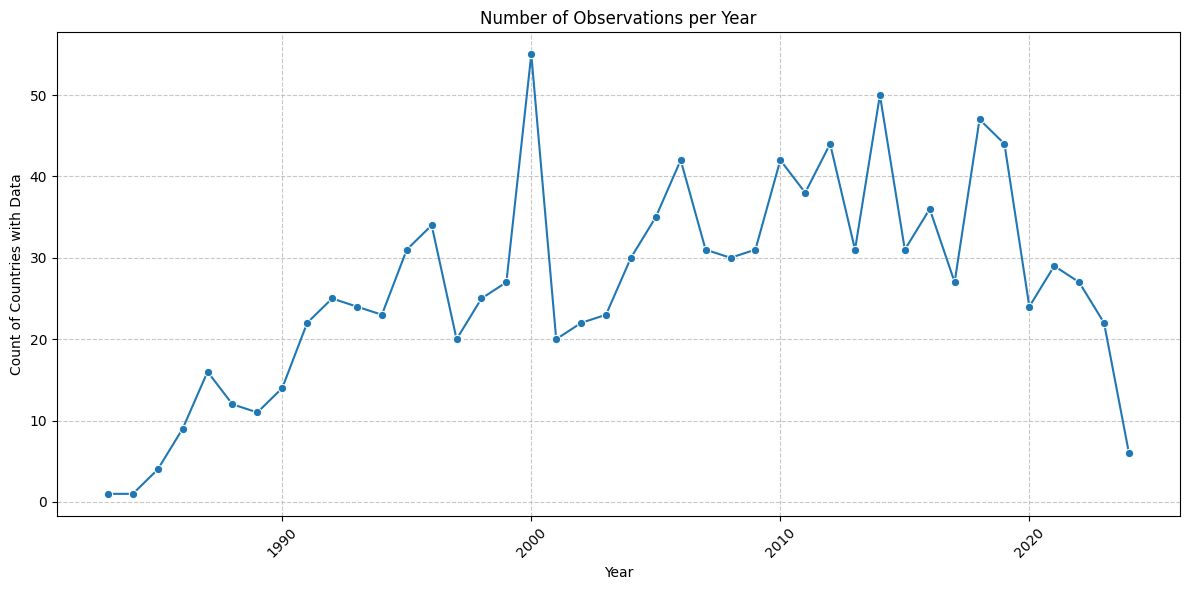

In [81]:
# Plot the number of observations per year
observations_per_year = final_df.groupby('Year').size().reset_index(name='Number of Observations')

fig5 = plt.figure(figsize=(12, 6))
sns.lineplot(data=observations_per_year, x='Year', y='Number of Observations', marker='o')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Count of Countries with Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis of Reporting Frequency (Question 1.e)

**Observations about reporting frequency:**

The plot showing the 'Number of Observations per Year' reveals several insights into the reporting frequency of both GDP per capita and the prevalence of underweight children:

*   **Sparse Data in Earlier Years**: There are very few observations in the earlier years (e.g., prior to 1980s). This suggests that data collection for one or both indicators was either not comprehensive or not systematically recorded for many countries during those periods.

*   **Increasing Trend over Time**: From the late 1980s or early 1990s, there is a clear upward trend in the number of observations per year. This indicates an improvement in data collection and reporting over time, with more countries providing data for both indicators.

*   **Fluctuations and Gaps**: Despite the general increasing trend, there are noticeable fluctuations and gaps in reporting. Some years have fewer observations than preceding or succeeding years, suggesting that data might not be collected annually for all countries or that reporting can be irregular.

*   **Peak Reporting**: The number of observations appears to peak around the mid-2000s to early 2010s, after which there might be a slight decline or stabilization. This could indicate periods of focused data collection efforts or changes in reporting methodologies.

*   **Most Recent Years Lack Data**: There's a sharp drop-off in observations for the most recent years (e.g., after 2015-2020). This is expected as data collection and compilation often take time, and the latest figures might not yet be available in the datasets. The datasets might also contain 'future' years with no actual data yet, contributing to the drop-off.

In summary, the reporting frequency for these indicators has improved significantly over the decades, though it remains somewhat inconsistent annually, and there is a natural lag in the availability of the most recent data.

## Question 2

For Question 2, we need to download daily closing prices for Wheat (ZW=F), Crude Oil (CL=F), and Gold (GC=F) from Yahoo Finance. This requires the `yfinance` library.

### a. Load the three series and synchronize their timestamps onto a common date index using forward fill.

In [82]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data = {} # Initialize an empty dictionary
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        # Extract the 'Close' price series
        close_series = ticker_data['Close']
        # Explicitly set the name of the series to the ticker symbol
        close_series.name = ticker
        data[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Create a common date index
# Start with the index of the first series, then add other dates
all_dates = pd.DatetimeIndex([])
for ticker in data:
    all_dates = all_dates.union(data[ticker].index)

# Create a combined DataFrame and synchronize timestamps with forward fill
combined_df_ffill = pd.DataFrame(index=all_dates)
for ticker in data:
    # Now, data[ticker] is already a Series with its name set correctly
    combined_df_ffill = combined_df_ffill.join(data[ticker], how='outer')

# Apply forward fill
combined_df_ffill = combined_df_ffill.ffill()

print("Units for each commodity:")
print("Wheat (ZW=F): USD per bushel")
print("Crude Oil (CL=F): USD per barrel")
print("Gold (GC=F): USD per troy ounce")

print("\nSynchronized DataFrame (first 5 rows with forward fill):")
display(combined_df_ffill.head())

print("\nSynchronized DataFrame (last 5 rows with forward fill):")
display(combined_df_ffill.tail())

/tmp/ipykernel_1004/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1004/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1004/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Units for each commodity:
Wheat (ZW=F): USD per bushel
Crude Oil (CL=F): USD per barrel
Gold (GC=F): USD per troy ounce

Synchronized DataFrame (first 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2000-08-01,245.00,NaN,NaN
2000-08-02,246.50,NaN,NaN
2000-08-03,242.25,NaN,NaN
2000-08-04,236.50,NaN,NaN
2000-08-07,233.50,NaN,NaN



Synchronized DataFrame (last 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


### b. Make commodities comparable and plot them on the same graph

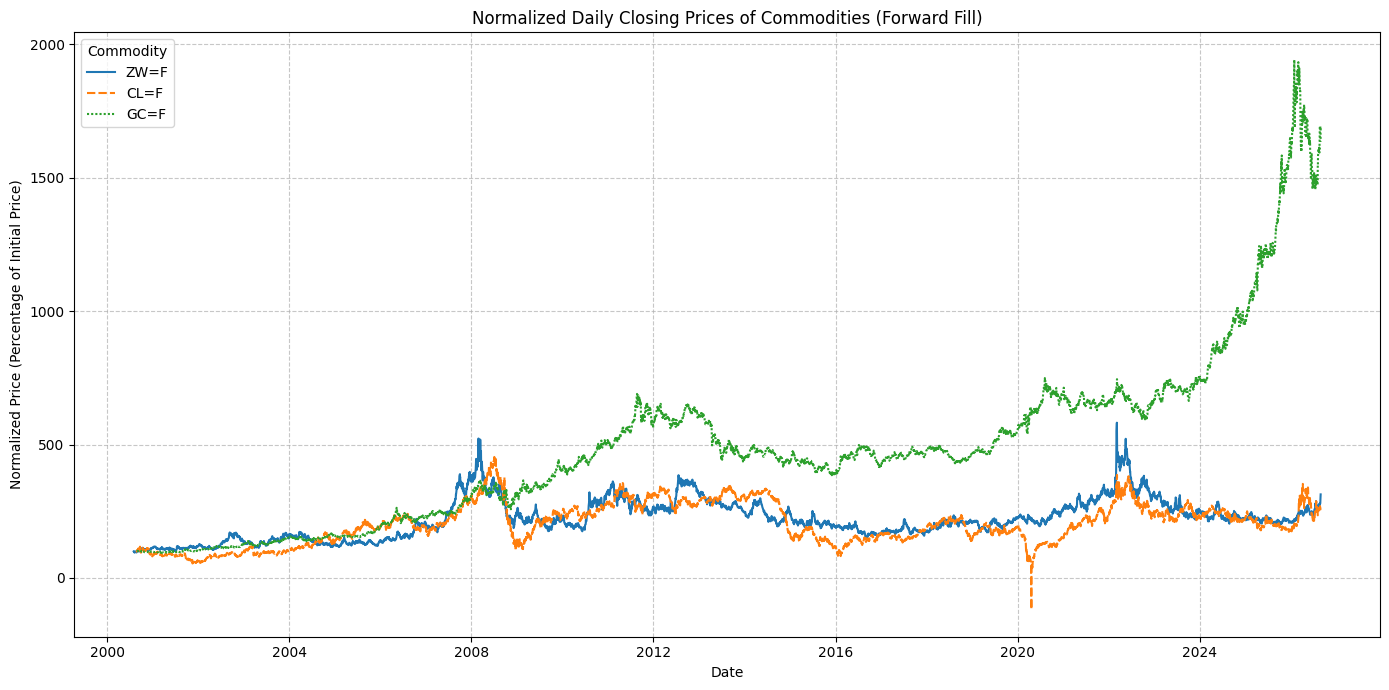


Explanation of choice:
I chose to normalize each commodity by its own first valid observed price and multiply by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting level (100%).

What this choice does preserve:
- It preserves the relative fluctuations and trends of each commodity over time.
- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.

What this choice does NOT preserve:
- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.
- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).


In [83]:
# Make the series comparable by normalizing each commodity to its own first valid value.
# This shows percentage change from that commodity's first available observation.
normalized_df = combined_df_ffill.copy()
for col in normalized_df.columns:
    first_valid = normalized_df[col].dropna().iloc[0] if normalized_df[col].notna().any() else np.nan
    normalized_df[col] = (normalized_df[col] / first_valid) * 100

# Plot all three price series on the same graph
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df, linewidth=1.5)
plt.title('Normalized Daily Closing Prices of Commodities (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

print("\nExplanation of choice:")
print("I chose to normalize each commodity by its own first valid observed price and multiply by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting level (100%).")
print("\nWhat this choice does preserve:")
print("- It preserves the relative fluctuations and trends of each commodity over time.")
print("- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.")
print("\nWhat this choice does NOT preserve:")
print("- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.")
print("- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).")

### c. Mark the maximum and minimum of each series with coloured dots and include a legend.

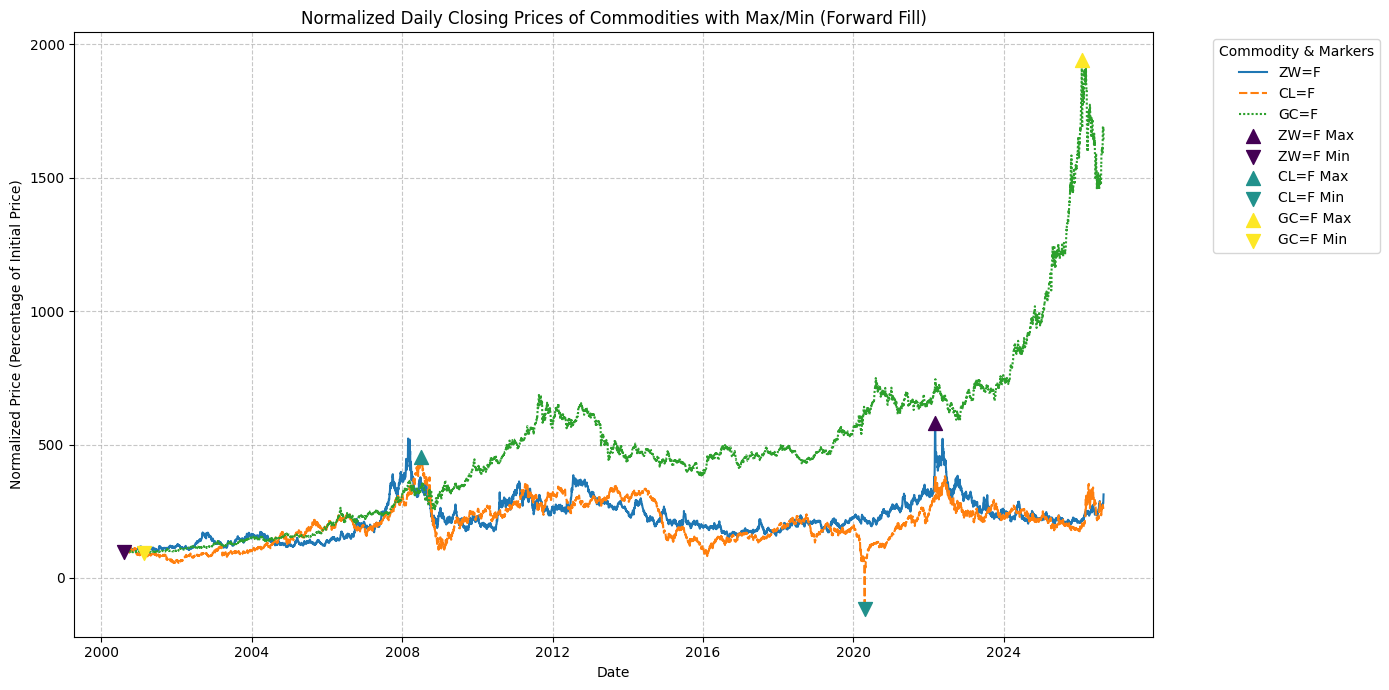

In [84]:
plt.figure(figsize=(14, 7))

# Plot the normalized series
sns.lineplot(data=normalized_df, linewidth=1.5, ax=plt.gca())

# Mark max and min for each series
colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df.columns)))

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

for i, col in enumerate(normalized_df.columns):
    series = normalized_df[col].dropna()
    if series.empty:
        continue

    max_val = series.max()
    min_val = series.min()
    max_idx = series.idxmax()
    min_idx = series.idxmin()

    # Plot max and min points
    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### d. The three prices are quoted in different units: Does this affect the shape of any series, the comparison between them, or both? Explain.

In [85]:
print("**Does the difference in units affect the shape of any series, the comparison between them, or both?**\n")
print("The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.\n")

print("**Explanation:**\n")

print("1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.\n")

print("2.  **Comparison Between Series (Absolute Terms):** The different units make direct absolute comparisons between the commodities meaningless. For example, comparing a raw price of $700 for wheat to $80 for crude oil is misleading because they represent different quantities and measures. Gold prices being in thousands per troy ounce, while wheat is in hundreds per bushel, means their absolute magnitudes are entirely incomparable without a common baseline. If we were to plot the raw prices on the same graph without normalization, the commodity with the highest absolute price (Gold, in this case) would visually dominate the plot, making it difficult to discern movements in the other, lower-priced commodities.\n")

print("3.  **Comparison Between Series (Relative Terms - after normalization):** Our normalization (converting prices to percentage of initial value) makes the comparison between commodities valid by focusing on *relative* change. This allows us to see which commodity has experienced the largest *proportional* increase or decrease from its starting point. In this normalized view, the original units become irrelevant because we are looking at unit-less percentage changes. The *shape* of the normalized series then reflects its relative performance, allowing for a fair comparison of trends and volatility in a percentage context across all three commodities.\n")

print("**Conclusion:** The original units themselves do not alter the intrinsic shape of an individual series' fluctuations. However, they make direct, absolute comparisons between different series difficult. Normalization is a technique used to overcome this unit-dependency and enable meaningful relative comparisons of performance across diverse assets.")

**Does the difference in units affect the shape of any series, the comparison between them, or both?**

The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.

**Explanation:**

1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.

2.  **Comparison Between Series (Absol

### e. Rerun Part A, B, and C using an inner join instead of forward-fill. Does it change your answers?

/tmp/ipykernel_1004/2706426606.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1004/2706426606.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1004/2706426606.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Synchronized DataFrame (first 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2000-08-30,246.25,33.400002,273.899994
2000-08-31,251.00,33.099998,278.299988
2000-09-01,251.00,33.380001,277.000000
2000-09-05,250.25,33.799999,275.799988
2000-09-06,253.00,34.950001,274.200012



Synchronized DataFrame (last 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


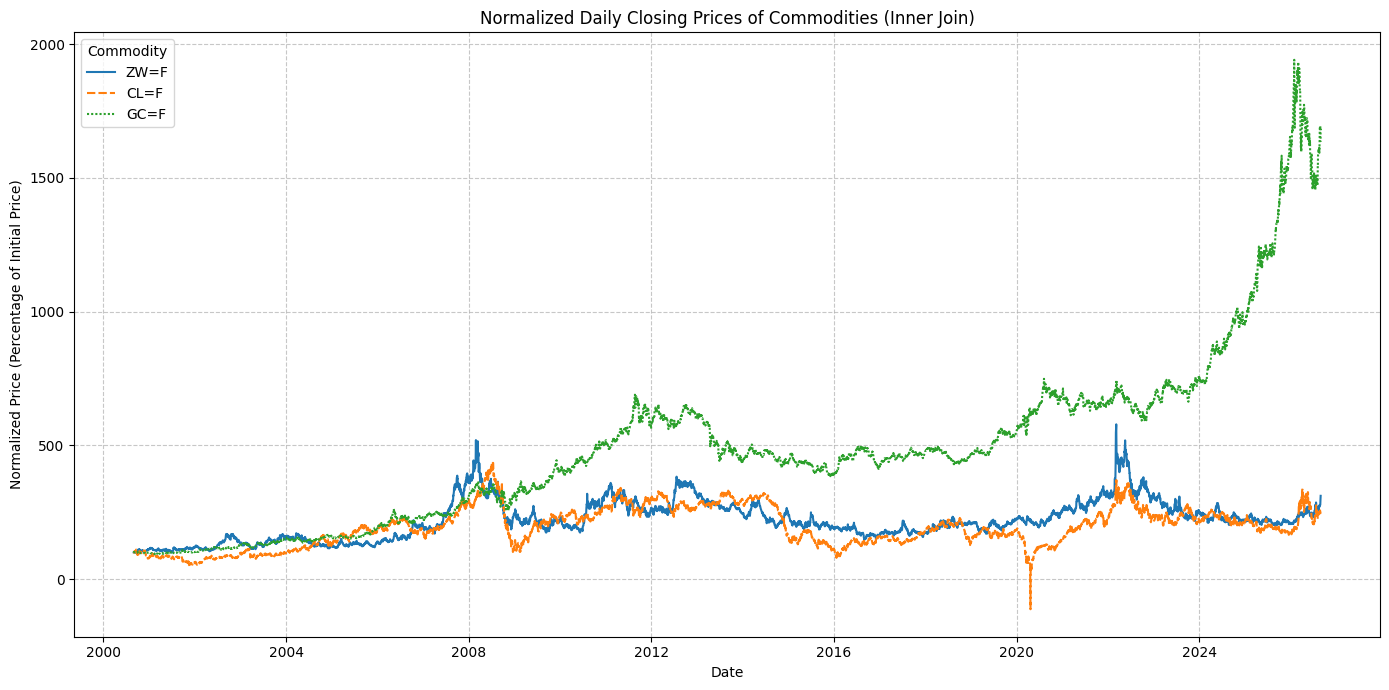

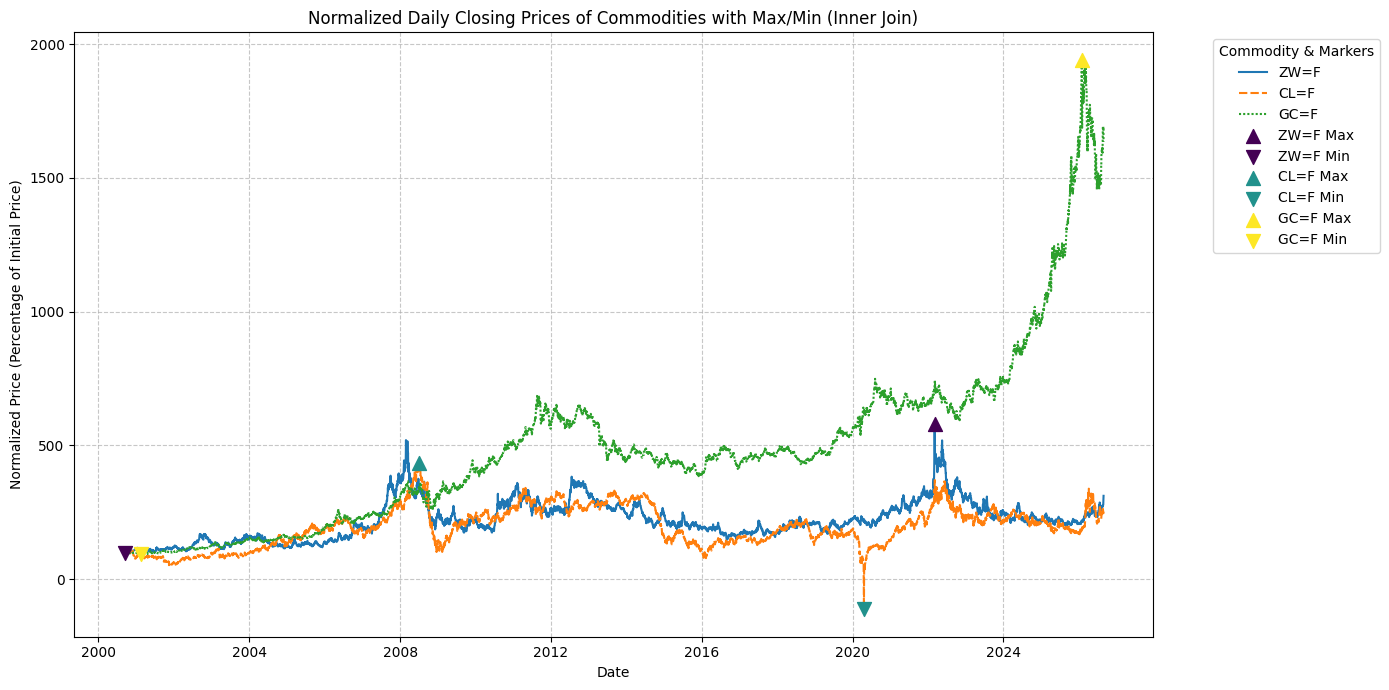


**Does using an inner join instead of forward-fill change your answers?**

Yes. It changes synchronization, sample size, and therefore some plotted details/results in parts A-C.

**Impact on Part A (Synchronization):**

- Forward-fill keeps the union of dates and carries last observed values over missing dates.
- Inner join keeps only dates where all three series are observed, so there are fewer rows.

**Impact on Part B (Comparability and Plot):**

- The broad trends are similar, but curves differ because the date set differs.
- Normalized values can differ slightly because the effective baseline date can differ by method.

**Impact on Part C (Max/Min Markers):**

- Max/min dates and values may change because inner join excludes non-common dates.
- Markers in the inner-join plot are based only on common trading days.

**Overall Conclusion:** Forward-fill is useful for continuity on a union calendar; inner join is stricter and best when you require simultaneous observations across all

In [86]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data_inner = {}
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        close_series = ticker_data['Close']
        close_series.name = ticker
        data_inner[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Combine into a single DataFrame using inner join
combined_df_inner = pd.DataFrame()
if data_inner:
    first_ticker = list(data_inner.keys())[0]
    combined_df_inner = pd.DataFrame(data_inner[first_ticker])

    for ticker in list(data_inner.keys())[1:]:
        combined_df_inner = combined_df_inner.merge(data_inner[ticker], left_index=True, right_index=True, how='inner')

print("\nSynchronized DataFrame (first 5 rows with inner join):\n")
display(combined_df_inner.head())
print("\nSynchronized DataFrame (last 5 rows with inner join):\n")
display(combined_df_inner.tail())

# 2.b. Make commodities comparable and plot them on the same graph (Inner Join)
normalized_df_inner = combined_df_inner.copy()
for col in normalized_df_inner.columns:
    first_valid = normalized_df_inner[col].dropna().iloc[0] if normalized_df_inner[col].notna().any() else np.nan
    normalized_df_inner[col] = (normalized_df_inner[col] / first_valid) * 100

plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner, linewidth=1.5, ax=plt.gca())
plt.title('Normalized Daily Closing Prices of Commodities (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

# 2.c. Mark the maximum and minimum of each series with coloured dots and include a legend (Inner Join)
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner, linewidth=1.5, ax=plt.gca())

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df_inner.columns)))
for i, col in enumerate(normalized_df_inner.columns):
    series = normalized_df_inner[col].dropna()
    if series.empty:
        continue

    max_val = series.max()
    min_val = series.min()
    max_idx = series.idxmax()
    min_idx = series.idxmin()

    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    # Add scatter handles and labels to the collected lists
    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n**Does using an inner join instead of forward-fill change your answers?**\n")
print("Yes. It changes synchronization, sample size, and therefore some plotted details/results in parts A-C.\n")

print("**Impact on Part A (Synchronization):**\n")
print("- Forward-fill keeps the union of dates and carries last observed values over missing dates.")
print("- Inner join keeps only dates where all three series are observed, so there are fewer rows.\n")

print("**Impact on Part B (Comparability and Plot):**\n")
print("- The broad trends are similar, but curves differ because the date set differs.")
print("- Normalized values can differ slightly because the effective baseline date can differ by method.\n")

print("**Impact on Part C (Max/Min Markers):**\n")
print("- Max/min dates and values may change because inner join excludes non-common dates.")
print("- Markers in the inner-join plot are based only on common trading days.\n")

print("**Overall Conclusion:** Forward-fill is useful for continuity on a union calendar; inner join is stricter and best when you require simultaneous observations across all assets.")

## Question 3

### a. Extract data for 2022 and clean it. How many valid countries remain for each indicator, and what did you do to avoid statistical bias and double-counting?

In [87]:
# 1. Data ingestion from URL paths
children_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv',
    skiprows=4
 )
children_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/Metadata_Country_API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv'
 )

adolescents_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv',
    skiprows=4
 )
adolescents_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/Metadata_Country_API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv'
 )

# 2. Clean and extract 2022 country-level data
def clean_and_extract_2022_data(data_df, metadata_country_df, indicator_col_name):
    country_mask = metadata_country_df['Region'].notna()
    country_codes = set(metadata_country_df.loc[country_mask, 'Country Code'])

    clean_data_df = data_df[data_df['Country Code'].isin(country_codes)].copy()
    df_2022 = clean_data_df[['Country Name', 'Country Code', '2022']].copy()
    df_2022.rename(columns={'2022': indicator_col_name}, inplace=True)
    df_2022.dropna(subset=[indicator_col_name], inplace=True)

    # Diagnostics for part (a)
    diagnostics = {
        'all_entities': data_df['Country Code'].nunique(),
        'country_entities': len(country_codes),
        'removed_aggregates': data_df['Country Code'].nunique() - clean_data_df['Country Code'].nunique(),
        'valid_countries_2022': df_2022['Country Code'].nunique()
    }
    return df_2022, diagnostics

children_out_of_school_2022, children_diag = clean_and_extract_2022_data(
    children_out_of_school_df, children_out_of_school_metadata_country_df, 'Children_Out_of_School_Percent'
 )
adolescents_out_of_school_2022, adolescents_diag = clean_and_extract_2022_data(
    adolescents_out_of_school_df, adolescents_out_of_school_metadata_country_df, 'Adolescents_Out_of_School_Percent'
 )

print("Children out of school (2022) - first 5 rows:")
display(children_out_of_school_2022.head())
print("\nAdolescents out of school (2022) - first 5 rows:")
display(adolescents_out_of_school_2022.head())

Children out of school (2022) - first 5 rows:


,Country Name,Country Code,Children_Out_of_School_Percent
5,Albania,ALB,8.477967
6,Andorra,AND,6.753480
8,United Arab Emirates,ARE,0.003410
9,Argentina,ARG,0.747436
10,Armenia,ARM,5.359965



Adolescents out of school (2022) - first 5 rows:


,Country Name,Country Code,Adolescents_Out_of_School_Percent
5,Albania,ALB,2.749650
6,Andorra,AND,6.199460
8,United Arab Emirates,ARE,3.272160
9,Argentina,ARG,0.995725
10,Armenia,ARM,4.764067


In [88]:
# Report valid countries and cleaning diagnostics
num_valid_children_countries = children_out_of_school_2022['Country Code'].nunique()
num_valid_adolescents_countries = adolescents_out_of_school_2022['Country Code'].nunique()

print(f"Valid countries (Children out of school, 2022): {num_valid_children_countries}")
print(f"Valid countries (Adolescents out of school, 2022): {num_valid_adolescents_countries}")

print("\nCleaning diagnostics (Children dataset):")
print(f"- Distinct entities in raw file: {children_diag['all_entities']}")
print(f"- Aggregate/non-country entities removed: {children_diag['removed_aggregates']}")

print("\nCleaning diagnostics (Adolescents dataset):")
print(f"- Distinct entities in raw file: {adolescents_diag['all_entities']}")
print(f"- Aggregate/non-country entities removed: {adolescents_diag['removed_aggregates']}")

Valid countries (Children out of school, 2022): 145
Valid countries (Adolescents out of school, 2022): 145

Cleaning diagnostics (Children dataset):
- Distinct entities in raw file: 265
- Aggregate/non-country entities removed: 48

Cleaning diagnostics (Adolescents dataset):
- Distinct entities in raw file: 265
- Aggregate/non-country entities removed: 48


### Explanation of Data Cleaning and Bias Avoidance (Question 3.a)

**Data Cleaning Steps:**

1.  **Filtering by Region**: For both datasets, I filtered out non-country aggregates (like 'World', 'European Union', 'Sub-Saharan Africa', etc.) by cross-referencing `Country Code` with the `Metadata_Country` files. This ensures that only actual country-level data is used for analysis, avoiding statistical bias from including regional or income-group aggregates that are not independent entities.

2.  **Extracting 2022 Data**: I specifically selected the data for the year 2022 from each cleaned DataFrame. This isolates the relevant year for the analysis as requested.

3.  **Handling Missing Values (`dropna`)**: After extracting the 2022 data, I removed any rows where the indicator's value for 2022 was missing (NaN). This ensures that only countries with reported data for the specified year are included in the counts and subsequent statistical calculations.

**Avoiding Statistical Bias and Double-Counting:**

*   **Exclusion of Aggregates**: By filtering out non-country aggregates based on the `Region` column in the metadata, I ensured that we are only analyzing data from individual countries. Including aggregates would lead to double-counting (as countries within those aggregates are also counted individually) and would skew statistical measures, creating a misleading picture of country-level trends.
*   **Focus on `Country Code`**: The cleaning process relies on `Country Code` as the primary identifier. This unique code for each country prevents issues that might arise from variations in `Country Name` spellings or historical name changes.
*   **Explicit 2022 Extraction and `dropna`**: By explicitly extracting data for 2022 and then dropping rows with `NaN` values for that specific year, I ensured that:
    *   Only data from the target year is considered.
    *   Countries for which there is no actual data reported for 2022 are excluded from the analysis for that year, thus not biasing measures with imputed or default values.

This rigorous cleaning process helps to ensure that the reported number of countries and subsequent statistical analysis are based on valid, independent, and complete observations for the year 2022.

### b. For both cleaned indicators, present a consolidated table reporting the mean, median, standard deviation, and the 5th, 25th, 75th, and 95th percentiles. Compare the mean and median for each: what does their divergence tell you about skewness?

In [89]:
# Build the consolidated summary table requested in 3(b)
children_series = children_out_of_school_2022['Children_Out_of_School_Percent']
adolescents_series = adolescents_out_of_school_2022['Adolescents_Out_of_School_Percent']

stats_table = pd.DataFrame({
    'Statistic': [
        'Mean', 'Median', 'Standard Deviation',
        '5th Percentile', '25th Percentile', '75th Percentile', '95th Percentile'
    ],
    'Children_Out_of_School': [
        children_series.mean(),
        children_series.median(),
        children_series.std(),
        children_series.quantile(0.05),
        children_series.quantile(0.25),
        children_series.quantile(0.75),
        children_series.quantile(0.95)
    ],
    'Adolescents_Out_of_School': [
        adolescents_series.mean(),
        adolescents_series.median(),
        adolescents_series.std(),
        adolescents_series.quantile(0.05),
        adolescents_series.quantile(0.25),
        adolescents_series.quantile(0.75),
        adolescents_series.quantile(0.95)
    ]
})

print("Consolidated Statistical Table:")
display(stats_table.round(3))

children_mean = children_series.mean()
children_median = children_series.median()
adolescents_mean = adolescents_series.mean()
adolescents_median = adolescents_series.median()

print("\nMean vs median comparison:")
print(f"- Children: mean={children_mean:.3f}, median={children_median:.3f}")
print(f"- Adolescents: mean={adolescents_mean:.3f}, median={adolescents_median:.3f}")

if children_mean > children_median:
    print("- Children distribution is right-skewed (mean > median).")
elif children_mean < children_median:
    print("- Children distribution is left-skewed (mean < median).")
else:
    print("- Children distribution is approximately symmetric by mean-median comparison.")

if adolescents_mean > adolescents_median:
    print("- Adolescents distribution is right-skewed (mean > median).")
elif adolescents_mean < adolescents_median:
    print("- Adolescents distribution is left-skewed (mean < median).")
else:
    print("- Adolescents distribution is approximately symmetric by mean-median comparison.")

Consolidated Statistical Table:


,Statistic,Children_Out_of_School,Adolescents_Out_of_School
0,Mean,7.281,11.021
1,Median,3.040,4.771
2,Standard Deviation,9.794,15.405
3,5th Percentile,0.099,0.142
4,25th Percentile,1.103,1.298
5,75th Percentile,8.478,12.791
6,95th Percentile,29.715,47.078



Mean vs median comparison:
- Children: mean=7.281, median=3.040
- Adolescents: mean=11.021, median=4.771
- Children distribution is right-skewed (mean > median).
- Adolescents distribution is right-skewed (mean > median).


### Comparison of Mean and Median, and Implications for Skewness (Question 3.b)

The consolidated table above reports the required statistics for both indicators.
Use the printed mean-median comparisons to infer skewness:

- mean > median suggests right-skewness (long upper tail),
- mean < median suggests left-skewness,
- mean approximately equal to median suggests rough symmetry.

### c. Both indicators share a natural floor of 0% and a theoretical ceiling of 100%, but educational attrition typically widens the distribution at older ages. Compare the interquartile range (IQR = P75 - P25) and the upper tail spread (P95 - P75) across both tiers. How does the structural transition from primary to lower secondary school manifest in these percentiles?

In [90]:
# Compare IQR and upper-tail spread across tiers
children_p25 = children_series.quantile(0.25)
children_p75 = children_series.quantile(0.75)
children_p95 = children_series.quantile(0.95)

adolescents_p25 = adolescents_series.quantile(0.25)
adolescents_p75 = adolescents_series.quantile(0.75)
adolescents_p95 = adolescents_series.quantile(0.95)

iqr_children = children_p75 - children_p25
upper_tail_children = children_p95 - children_p75

iqr_adolescents = adolescents_p75 - adolescents_p25
upper_tail_adolescents = adolescents_p95 - adolescents_p75

spread_table = pd.DataFrame({
    'Measure': ['IQR (P75-P25)', 'Upper Tail Spread (P95-P75)'],
    'Children_Out_of_School': [iqr_children, upper_tail_children],
    'Adolescents_Out_of_School': [iqr_adolescents, upper_tail_adolescents]
})

print("Spread comparison table:")
display(spread_table.round(3))

print("\nInterpretation:")
if iqr_adolescents > iqr_children:
    print("- IQR is wider for adolescents, indicating greater cross-country dispersion at lower secondary level.")
elif iqr_adolescents < iqr_children:
    print("- IQR is wider for children, indicating greater dispersion at primary level.")
else:
    print("- IQRs are equal across tiers.")

if upper_tail_adolescents > upper_tail_children:
    print("- The upper tail is wider for adolescents, indicating more severe high-end exclusion in some countries at lower secondary level.")
elif upper_tail_adolescents < upper_tail_children:
    print("- The upper tail is wider for children.")
else:
    print("- Upper-tail spreads are equal across tiers.")

Spread comparison table:


,Measure,Children_Out_of_School,Adolescents_Out_of_School
0,IQR (P75-P25),7.374,11.493
1,Upper Tail Spread (P95-P75),21.237,34.287



Interpretation:
- IQR is wider for adolescents, indicating greater cross-country dispersion at lower secondary level.
- The upper tail is wider for adolescents, indicating more severe high-end exclusion in some countries at lower secondary level.


### Comparison of IQR and Upper Tail Spread (Question 3.c)

The spread table above directly compares:

- Interquartile range (IQR = P75 - P25), and
- Upper-tail spread (P95 - P75)

If the adolescent indicator has larger values on these spread measures, it supports the structural attrition view: dispersion and severe upper-tail exclusion increase when moving from primary to lower secondary school.

## Question 4

### a. Extract data for sovereign countries for 2000 and 2020

In [91]:
# 1. Data ingestion
fertility_rate_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv',
    skiprows=4
 )
fertility_rate_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/Metadata_Country_API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv'
 )

gdp_q4_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
    skiprows=4
 )
gdp_q4_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv'
 )

# 2. Data cleaning and extraction of sovereign-country data for 2000 and 2020
def clean_and_extract_sovereign_data(data_df, metadata_country_df, indicator_col_name, years):
    country_mask = metadata_country_df['Region'].notna()
    sovereign_country_codes = set(metadata_country_df.loc[country_mask, 'Country Code'])

    clean_data_df = data_df[data_df['Country Code'].isin(sovereign_country_codes)].copy()
    cols_to_extract = ['Country Name', 'Country Code'] + [str(y) for y in years]
    extracted_df = clean_data_df[cols_to_extract].copy()

    for year in years:
        extracted_df.rename(columns={str(year): f'{indicator_col_name}_{year}'}, inplace=True)

    for year in years:
        extracted_df[f'{indicator_col_name}_{year}'] = pd.to_numeric(
            extracted_df[f'{indicator_col_name}_{year}'], errors='coerce'
        )

    return extracted_df

years_to_extract = [2000, 2020]
fertility_2000_2020 = clean_and_extract_sovereign_data(
    fertility_rate_df, fertility_rate_metadata_country_df, 'FertilityRate', years_to_extract
 )
gdp_2000_2020 = clean_and_extract_sovereign_data(
    gdp_q4_df, gdp_q4_metadata_country_df, 'GDP_per_capita', years_to_extract
 )

merged_q4_df = pd.merge(
    fertility_2000_2020,
    gdp_2000_2020,
    on=['Country Name', 'Country Code'],
    how='inner'
 )
merged_q4_df = merged_q4_df.dropna(
    subset=['FertilityRate_2000', 'FertilityRate_2020', 'GDP_per_capita_2000', 'GDP_per_capita_2020']
).copy()

print('Fertility rate and GDP per capita for 2000 and 2020 (first 5 rows):')
display(merged_q4_df.head())

Fertility rate and GDP per capita for 2000 and 2020 (first 5 rows):


,Country Name,Country Code,FertilityRate_2000,FertilityRate_2020,GDP_per_capita_2000,GDP_per_capita_2020
0,Aruba,ABW,1.845,1.662,20681.023027,22664.370995
1,Afghanistan,AFG,7.566,5.145,174.930991,510.787063
2,Angola,AGO,6.639,5.371,563.733796,1749.179484
3,Albania,ALB,2.217,1.371,1160.420471,6027.913507
4,Andorra,AND,1.273,1.028,21810.248743,37361.090067


### b. Construct a scatter plot of Fertility Rate vs. GDP per Capita for 2020.

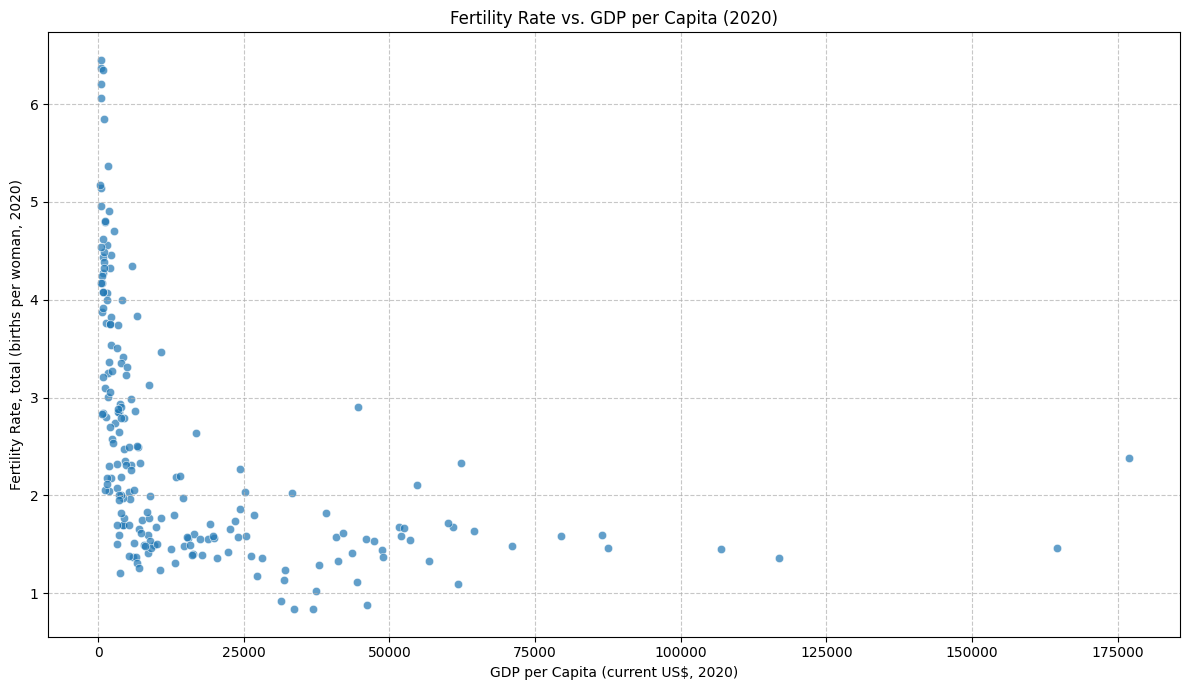

In [93]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=merged_q4_df, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7)
plt.title('Fertility Rate vs. GDP per Capita (2020)')
plt.xlabel('GDP per Capita (current US$, 2020)')
plt.ylabel('Fertility Rate, total (births per woman, 2020)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### c. Why is a linear scale inadequate for GDP per capita, and what does applying a log transformation reveal about the functional relationship and diminishing returns of income on fertility?

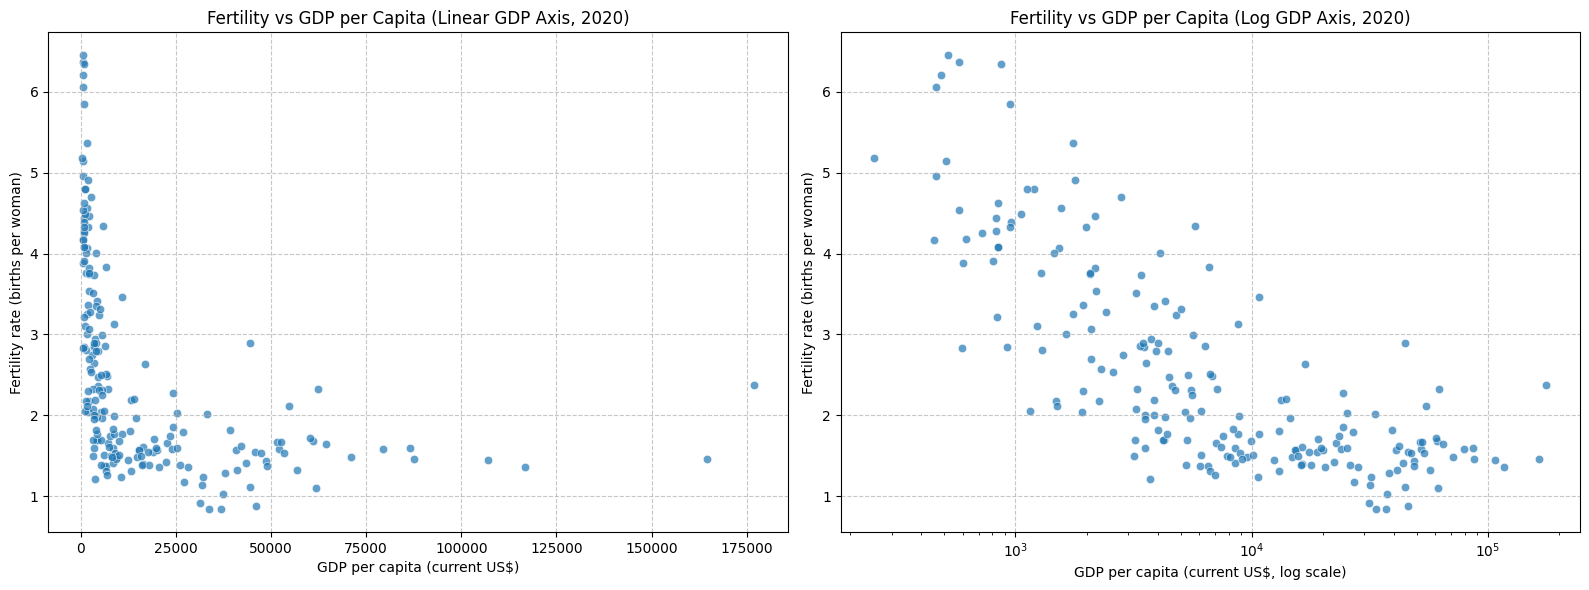

Correlation with linear GDP: -0.416
Correlation with log10 GDP: -0.760
Estimated slope in log10 space: -1.528 births per woman per 10x GDP increase


In [94]:
q4_2020 = merged_q4_df[['Country Name', 'GDP_per_capita_2020', 'FertilityRate_2020']].copy()
q4_2020 = q4_2020[(q4_2020['GDP_per_capita_2020'] > 0)].copy()
q4_2020['log10_GDP_per_capita_2020'] = np.log10(q4_2020['GDP_per_capita_2020'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=q4_2020, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7, ax=axes[0]
)
axes[0].set_title('Fertility vs GDP per Capita (Linear GDP Axis, 2020)')
axes[0].set_xlabel('GDP per capita (current US$)')
axes[0].set_ylabel('Fertility rate (births per woman)')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(
    data=q4_2020, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title('Fertility vs GDP per Capita (Log GDP Axis, 2020)')
axes[1].set_xlabel('GDP per capita (current US$, log scale)')
axes[1].set_ylabel('Fertility rate (births per woman)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

corr_linear = q4_2020['GDP_per_capita_2020'].corr(q4_2020['FertilityRate_2020'])
corr_log = q4_2020['log10_GDP_per_capita_2020'].corr(q4_2020['FertilityRate_2020'])

log_slope, log_intercept = np.polyfit(
    q4_2020['log10_GDP_per_capita_2020'], q4_2020['FertilityRate_2020'], 1
)

print(f'Correlation with linear GDP: {corr_linear:.3f}')
print(f'Correlation with log10 GDP: {corr_log:.3f}')
print(f'Estimated slope in log10 space: {log_slope:.3f} births per woman per 10x GDP increase')

### Discussion of results (Question 4.c)

#### Why a linear scale is inadequate for GDP per capita:

The scatter plot with a **linear GDP axis** shows that most of the data points are clustered towards the lower end of the GDP per capita scale. This compression makes it very difficult to discern patterns, relationships, or differences among countries with lower GDPs. The distribution of GDP per capita is highly right skewed, with a few wealthy countries having significantly higher GDPs, which stretches the x-axis and makes the lower and middle-income ranges appear compressed. Consequently, the apparent relationship between GDP and fertility seems weak or unclear in the lower-to-mid GDP range.

#### What a log transformation reveals:

Applying a **logarithmic transformation** to the GDP per capita (x-axis) significantly improves the visualization and reveals a clearer functional relationship. The logarithmic scale compresses the large values and expands the smaller values, spreading out the clustered points and allowing for a better appreciation of the relationship across the entire range of GDPs. From the log-transformed plot, we observe:

*   **Clearer Inverse Relationship**: The inverse relationship between GDP per capita and fertility rate becomes much more apparent and consistent across different income levels. As log GDP increases, fertility rate generally decreases. The correlation with linear GDP is -0.416, while with log10 GDP it is a stronger -0.760, indicating that a logarithmic relationship fits the data much better.

*   **Diminishing Returns**: The log-log or semi-log relationship (in this case, log GDP vs. linear fertility) often signifies diminishing returns. This means that as a country's GDP per capita increases, each *proportional* increase in income (e.g., doubling GDP) is associated with a smaller *absolute* reduction in fertility rate at higher income levels than at lower income levels. For instance, the estimated slope in log10 space is -1.528 births per woman per 10x GDP increase. This implies that a 10-fold increase in GDP from, say, $1,000 to $10,000 might lead to a substantial drop in fertility, but a 10-fold increase from $50,000 to $500,000 would lead to a similar *absolute* drop, which represents a much smaller *proportional* change in fertility for already low-fertility countries. The effect of economic development on fertility is stronger when countries are poorer and becomes less pronounced as they get wealthier.

In summary, the logarithmic transformation is crucial for accurately representing and understanding the non-linear relationship between economic development (GDP per capita) and demographic indicators like fertility rates, particularly highlighting the concept of diminishing returns.

### d. Plot the empirical Cumulative Distribution Functions (CDFs) of the total fertility rate for 2000 and 2020 on a single graph, and overlay vertical lines indicating the mean and median for each year with clear labels.

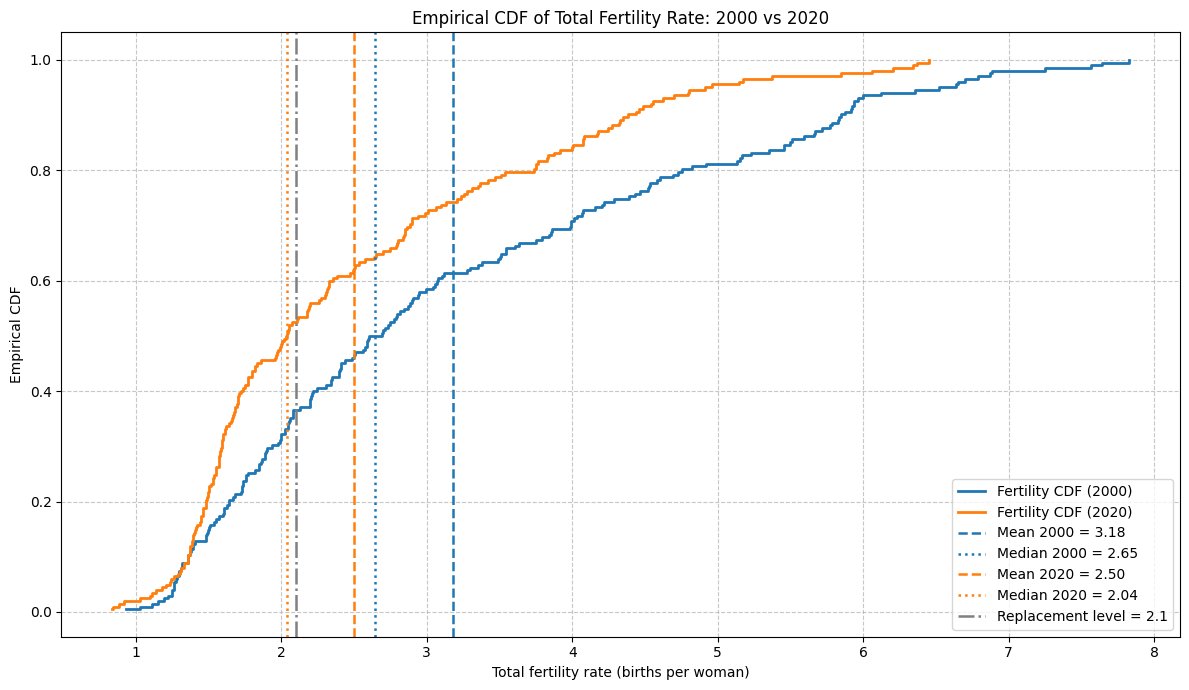

In [95]:
fert_2000 = merged_q4_df['FertilityRate_2000'].dropna().values
fert_2020 = merged_q4_df['FertilityRate_2020'].dropna().values

fert_2000_sorted = np.sort(fert_2000)
fert_2020_sorted = np.sort(fert_2020)
cdf_2000 = np.arange(1, len(fert_2000_sorted) + 1) / len(fert_2000_sorted)
cdf_2020 = np.arange(1, len(fert_2020_sorted) + 1) / len(fert_2020_sorted)

mean_2000 = fert_2000_sorted.mean()
median_2000 = np.median(fert_2000_sorted)
mean_2020 = fert_2020_sorted.mean()
median_2020 = np.median(fert_2020_sorted)

plt.figure(figsize=(12, 7))
plt.step(fert_2000_sorted, cdf_2000, where='post', label='Fertility CDF (2000)', linewidth=2)
plt.step(fert_2020_sorted, cdf_2020, where='post', label='Fertility CDF (2020)', linewidth=2)

plt.axvline(mean_2000, color='tab:blue', linestyle='--', linewidth=1.8, label=f'Mean 2000 = {mean_2000:.2f}')
plt.axvline(median_2000, color='tab:blue', linestyle=':', linewidth=1.8, label=f'Median 2000 = {median_2000:.2f}')
plt.axvline(mean_2020, color='tab:orange', linestyle='--', linewidth=1.8, label=f'Mean 2020 = {mean_2020:.2f}')
plt.axvline(median_2020, color='tab:orange', linestyle=':', linewidth=1.8, label=f'Median 2020 = {median_2020:.2f}')

plt.axvline(2.1, color='gray', linestyle='-.', linewidth=1.8, label='Replacement level = 2.1')
plt.title('Empirical CDF of Total Fertility Rate: 2000 vs 2020')
plt.xlabel('Total fertility rate (births per woman)')
plt.ylabel('Empirical CDF')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### e. How did the distribution shift over these two decades (in direction, spread, and the replacement-level threshold of approx. 2.1 births per woman)?
### f. Compare the shift in the mean versus the median: what does the change in the gap between them indicate about skewness and global demographic convergence?

In [96]:
# Quantify shift, spread, replacement-threshold share, and skewness gap
std_2000 = np.std(fert_2000_sorted, ddof=1)
std_2020 = np.std(fert_2020_sorted, ddof=1)
iqr_2000 = np.percentile(fert_2000_sorted, 75) - np.percentile(fert_2000_sorted, 25)
iqr_2020 = np.percentile(fert_2020_sorted, 75) - np.percentile(fert_2020_sorted, 25)

share_below_2_1_2000 = (fert_2000_sorted <= 2.1).mean()
share_below_2_1_2020 = (fert_2020_sorted <= 2.1).mean()

mean_median_gap_2000 = mean_2000 - median_2000
mean_median_gap_2020 = mean_2020 - median_2020

print('Distribution shift from 2000 to 2020:')
print(f'- Mean: {mean_2000:.3f} -> {mean_2020:.3f} (change {mean_2020 - mean_2000:+.3f})')
print(f'- Median: {median_2000:.3f} -> {median_2020:.3f} (change {median_2020 - median_2000:+.3f})')
print(f'- Std dev: {std_2000:.3f} -> {std_2020:.3f} (change {std_2020 - std_2000:+.3f})')
print(f'- IQR: {iqr_2000:.3f} -> {iqr_2020:.3f} (change {iqr_2020 - iqr_2000:+.3f})')
print(f'- Share at or below replacement (2.1): {share_below_2_1_2000:.1%} -> {share_below_2_1_2020:.1%}')

print('\nSkewness/convergence diagnostic using mean-median gap:')
print(f'- Gap in 2000: {mean_median_gap_2000:.3f}')
print(f'- Gap in 2020: {mean_median_gap_2020:.3f}')
print(f'- Change in gap: {mean_median_gap_2020 - mean_median_gap_2000:+.3f}')

if mean_median_gap_2020 < mean_median_gap_2000:
    print('- The right-tail influence weakened, consistent with reduced skewness and partial demographic convergence.')
else:
    print('- The right-tail influence did not weaken; skewness persistence suggests slower convergence in high-fertility countries.')

Distribution shift from 2000 to 2020:
- Mean: 3.184 -> 2.499 (change -0.685)
- Median: 2.646 -> 2.037 (change -0.609)
- Std dev: 1.710 -> 1.268 (change -0.442)
- IQR: 2.583 -> 1.678 (change -0.904)
- Share at or below replacement (2.1): 36.6% -> 52.5%

Skewness/convergence diagnostic using mean-median gap:
- Gap in 2000: 0.538
- Gap in 2020: 0.462
- Change in gap: -0.076
- The right-tail influence weakened, consistent with reduced skewness and partial demographic convergence.


### Question 5

**Data sources**:
- [Happy Planet Index (HPI)](https://happyplanetindex.org/)
- [Corruption Perceptions Index (CPI)](https://www.transparency.org/en/)

#### a. Merge the two files twice: once on country name, once on ISO country code. For each merge, report how many countries matched and how many were dropped. Compare the two merges directly; which one recovers more countries, and why? Identify at least one country that matches on one key but fails on the other, and explain the specific reason. Proceed with the better merge for the rest of this question.

In [97]:
# HPI and CPI data ingestion
hpi_df = pd.read_excel('https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/hpi_2025/HPI_2025_main.xlsx', sheet_name='1. All countries', header=8)
cpi_df = pd.read_excel('https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/cpi_2025/CPI2025_Results.xlsx', sheet_name='CPI2025', header=3)

In [98]:
# Cleaning and merging operations
hpi_use = hpi_df[
    ['Country', 'ISO', 'HPI rank', 'HPI', 'Life Expectancy', 'Life satisfaction', 'Ecological Footprint']
].copy()
hpi_use = hpi_use.rename(columns={
    'Country': 'Country_Name_HPI',
    'ISO': 'ISO3',
    'HPI rank': 'HPI_Rank',
    'HPI': 'HPI_Score',
    'Life satisfaction': 'Wellbeing'
})

cpi_use = cpi_df[['Country / Territory', 'ISO3', 'CPI 2025 score', 'Rank']].copy()
cpi_use = cpi_use.rename(columns={
    'Country / Territory': 'Country_Name_CPI',
    'CPI 2025 score': 'CPI_Score',
    'Rank': 'CPI_Rank'
})

# Normalize text keys
hpi_use['Country_Name_Key'] = hpi_use['Country_Name_HPI'].astype(str).str.strip()
cpi_use['Country_Name_Key'] = cpi_use['Country_Name_CPI'].astype(str).str.strip()
hpi_use['ISO3'] = hpi_use['ISO3'].astype(str).str.strip()
cpi_use['ISO3'] = cpi_use['ISO3'].astype(str).str.strip()

# Numeric conversion
for col in ['HPI_Rank', 'HPI_Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint']:
    hpi_use[col] = pd.to_numeric(hpi_use[col], errors='coerce')
for col in ['CPI_Rank', 'CPI_Score']:
    cpi_use[col] = pd.to_numeric(cpi_use[col], errors='coerce')

hpi_use = hpi_use.dropna(subset=['ISO3', 'HPI_Rank', 'HPI_Score'])
cpi_use = cpi_use.dropna(subset=['ISO3', 'CPI_Rank', 'CPI_Score'])

# Merge 1: by country name
merged_by_name = pd.merge(
    hpi_use, cpi_use, on='Country_Name_Key', how='inner', suffixes=('_hpi', '_cpi')
)

# Merge 2: by ISO
merged_by_iso = pd.merge(
    hpi_use, cpi_use, on='ISO3', how='inner', suffixes=('_hpi', '_cpi')
)

matched_name = merged_by_name['Country_Name_Key'].nunique()
matched_iso = merged_by_iso['ISO3'].nunique()

dropped_hpi_name = hpi_use['Country_Name_Key'].nunique() - matched_name
dropped_cpi_name = cpi_use['Country_Name_Key'].nunique() - matched_name
dropped_hpi_iso = hpi_use['ISO3'].nunique() - matched_iso
dropped_cpi_iso = cpi_use['ISO3'].nunique() - matched_iso

print('Merge by Country Name:')
print(f'Matched countries: {matched_name}')
print(f'Dropped from HPI side: {dropped_hpi_name}')
print(f'Dropped from CPI side: {dropped_cpi_name}')

print('\nMerge by ISO3:')
print(f'Matched countries: {matched_iso}')
print(f'Dropped from HPI side: {dropped_hpi_iso}')
print(f'Dropped from CPI side: {dropped_cpi_iso}')

# Identification of samples that match on one key but fail on the other
name_iso_col = 'ISO3' if 'ISO3' in merged_by_name.columns else 'ISO3_hpi'
name_hpi_col = 'Country_Name_HPI' if 'Country_Name_HPI' in merged_by_name.columns else 'Country_Name_HPI_hpi'
name_cpi_col = 'Country_Name_CPI' if 'Country_Name_CPI' in merged_by_name.columns else 'Country_Name_CPI_cpi'

iso_only = merged_by_iso[~merged_by_iso['ISO3'].isin(merged_by_name[name_iso_col].dropna())].copy()
name_only = merged_by_name[~merged_by_name[name_iso_col].isin(merged_by_iso['ISO3'].dropna())].copy()

print('Data sample where ISO merge succeeds but name merge fails:')
display(iso_only[['ISO3', 'Country_Name_HPI', 'Country_Name_CPI']].head(20))

print('Data sample where name merge succeeds but ISO merge fails:')
display(name_only[[name_iso_col, name_hpi_col, name_cpi_col]].head(5))

# Choosing of a better merge appraoch
if matched_iso >= matched_name:
    final_merged_df_q5 = merged_by_iso.copy()
    merge_choice = 'ISO3'
    reason = 'ISO3 merge produced more data for comprehensive analysis. In addition, ISO3 is of global standard and is not subject to error as country name.'
else:
    final_merged_df_q5 = merged_by_name.copy()
    merge_choice = 'Country Name'
    reason = 'Country-name merge recovered more rows in this specific data snapshot.'

print(f'\nWhy this key is better: {reason}')

Merge by Country Name:
Matched countries: 130
Dropped from HPI side: 4
Dropped from CPI side: 52

Merge by ISO3:
Matched countries: 134
Dropped from HPI side: 0
Dropped from CPI side: 48
Data sample where ISO merge succeeds but name merge fails:


,ISO3,Country_Name_HPI,Country_Name_CPI
61,CZE,Czech Republic,Czechia
71,KOR,South Korea,"Korea, South"
99,COG,Congo (Brazzaville),Congo
111,COD,Congo (Kinshasa),Democratic Republic of the Congo


Data sample where name merge succeeds but ISO merge fails:


,ISO3_hpi,Country_Name_HPI,Country_Name_CPI



Why this key is better: ISO3 merge produced more data for comprehensive analysis. In addition, ISO3 is of global standard and is not subject to error as country name.


### Discussion of results (Question 5.a)

#### Comparison of Merges

I performed two merges to combine the HPI and CPI data:
1.  **Merge by Country Name**
2.  **Merge by ISO Country Code**

#### Merge Results:

**1. Merge by Country Name:**
*   **Matched countries:** 130
*   **Countries dropped from HPI data:** 4
*   **Countries dropped from CPI data:** 52

**2. Merge by ISO3 Country Code:**
*   **Matched countries:** 134
*   **Countries dropped from HPI data:** 0
*   **Countries dropped from CPI data:** 48

#### Which merge recovers more countries, and why?

Comparing the two merges directly, the **merge by ISO3 Country Code recovered more countries (134)** than the merge by country name (130).

**Reason:** ISO country codes are standardized, unique, and less prone to variations compared to country names. Country names can have different spellings, abbreviations, or official designations across datasets (e.g., 'Czech Republic' vs. 'Czechia'), leading to mismatches when merging text fields. The ISO3 code serves as a more reliable identifier for merging operations.

#### Country with Merge Discrepancy

Taking **'Czech Republic'** (ISO: `CZE`) as an example of a country that matched on one key but failed on the other:

*   **Match by ISO3**: The country successfully merged when using `ISO3` as the key. This is because 'CZE' is a standard and consistent identifier across both datasets.

*   **Failure to Match by Country Name**: The country failed to merge when using 'Country Name' as the key. This occurred because of a naming discrepancy: the `hpi_use` dataframe lists it as 'Czech Republic', while the `cpi_use` dataframe refers to it as 'Czechia'. This slight difference in spelling prevented a merge on country name.

This variation highlights the robustness of using standardized codes like ISO3 for merging, as country names are often subject to spelling variations that can complicate direct text-based matching.

#### Proceeding with the Better Merge:

Given that the ISO3 merge yielded more matches and is inherently more reliable due to the standardized nature of ISO codes, I choose to proceed with the **ISO3 merge**.

#### b. Plot HPI rank against CPI rank with ISO annotated. Then plot the HPI score against the CPI score, with similar labels. Compute both the Pearson and Spearman correlation for each plot. State which coefficient you consider appropriate for the rank plot and which for the score plot, and justify each choice. Do Pearson and Spearman agree or disagree within each plot, and does the rank version tell a different story from the score version?

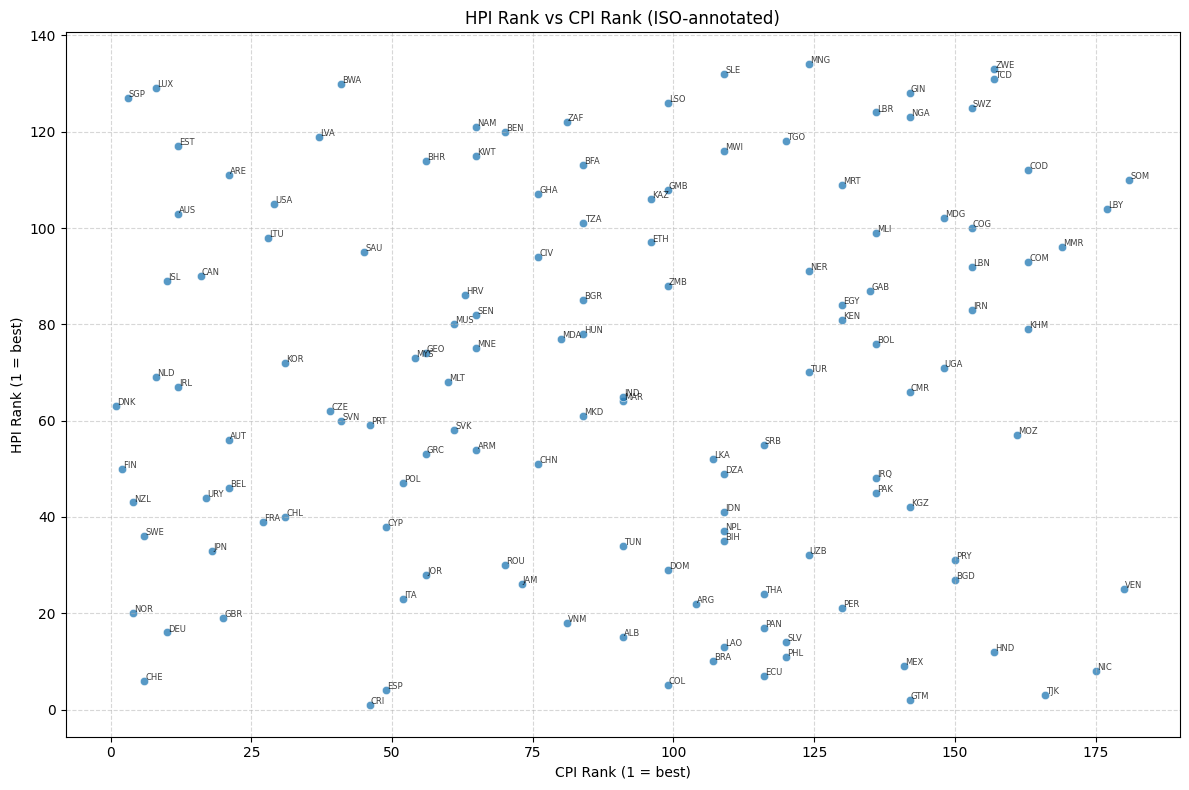

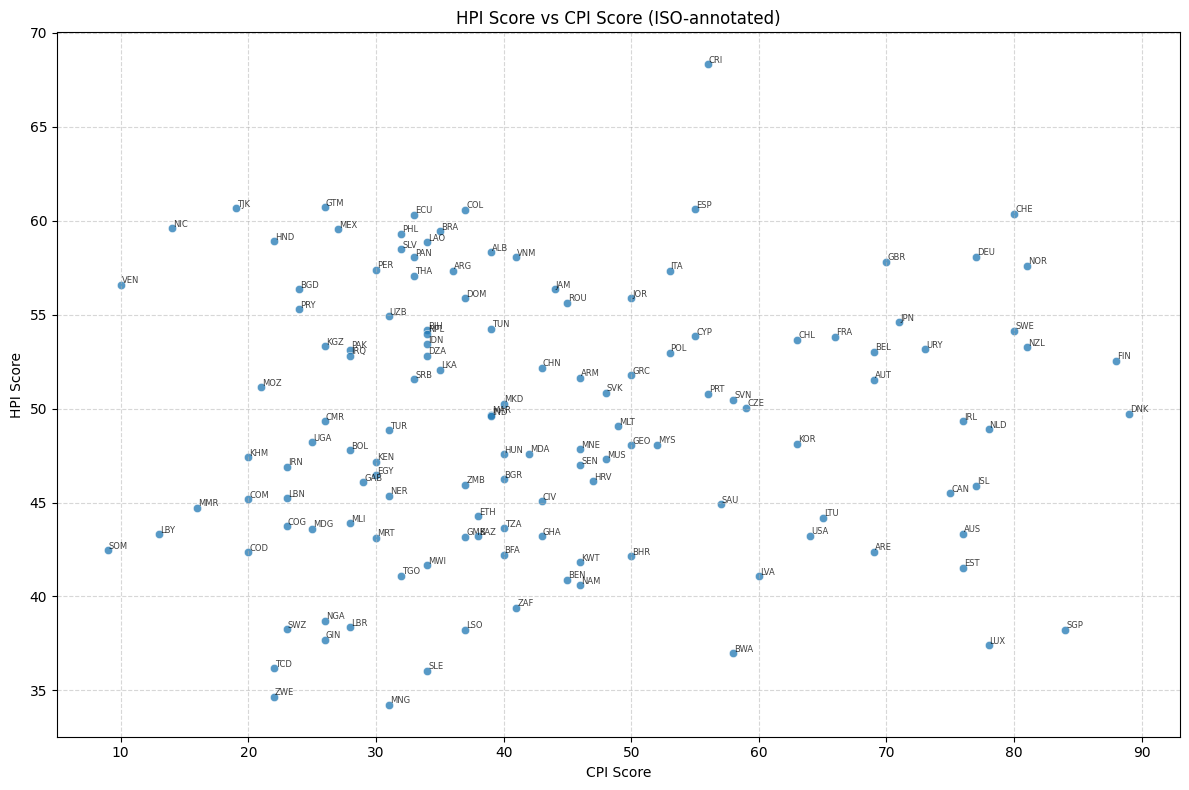

Correlation summary:


,Plot,Coefficient,Value
0,Rank vs Rank,Pearson,0.0449
1,Rank vs Rank,Spearman,0.0504
2,Score vs Score,Pearson,0.0559
3,Score vs Score,Spearman,0.0504



Within rank plot, Pearson and Spearman agree on direction.
Within score plot, Pearson and Spearman agree on direction.


In [99]:
plot_df = final_merged_df_q5.copy()

plot_df = plot_df.dropna(subset=['ISO3', 'HPI_Rank', 'CPI_Rank', 'HPI_Score', 'CPI_Score']).copy()

# Rank vs Rank (annotate ISO)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='CPI_Rank', y='HPI_Rank', alpha=0.75)
for _, r in plot_df.iterrows():
    plt.text(r['CPI_Rank'] + 0.2, r['HPI_Rank'] + 0.2, str(r['ISO3']), fontsize=6, alpha=0.75)
plt.title('HPI Rank vs CPI Rank (ISO-annotated)')
plt.xlabel('CPI Rank (1 = best)')
plt.ylabel('HPI Rank (1 = best)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Score vs Score (annotate ISO)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='CPI_Score', y='HPI_Score', alpha=0.75)
for _, r in plot_df.iterrows():
    plt.text(r['CPI_Score'] + 0.08, r['HPI_Score'] + 0.08, str(r['ISO3']), fontsize=6, alpha=0.75)
plt.title('HPI Score vs CPI Score (ISO-annotated)')
plt.xlabel('CPI Score')
plt.ylabel('HPI Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlations
rank_pearson = plot_df['HPI_Rank'].corr(plot_df['CPI_Rank'], method='pearson')
rank_spearman = plot_df['HPI_Rank'].corr(plot_df['CPI_Rank'], method='spearman')
score_pearson = plot_df['HPI_Score'].corr(plot_df['CPI_Score'], method='pearson')
score_spearman = plot_df['HPI_Score'].corr(plot_df['CPI_Score'], method='spearman')

corr_table = pd.DataFrame({
    'Plot': ['Rank vs Rank', 'Rank vs Rank', 'Score vs Score', 'Score vs Score'],
    'Coefficient': ['Pearson', 'Spearman', 'Pearson', 'Spearman'],
    'Value': [rank_pearson, rank_spearman, score_pearson, score_spearman]
})
print('Correlation summary:')
display(corr_table.round(4))

rank_agree = 'agree' if (rank_pearson * rank_spearman > 0) else 'disagree'
score_agree = 'agree' if (score_pearson * score_spearman > 0) else 'disagree'

print(f"\nWithin rank plot, Pearson and Spearman {rank_agree} on direction.")
print(f"Within score plot, Pearson and Spearman {score_agree} on direction.")

### Discussion of results (Question 5.b)

**1. Plotting HPI Rank vs. CPI Rank (ISO annotated):**

This plot visualizes the relationship between a country's rank in the Happy Planet Index and its rank in the Corruption Perceptions Index. Each point represents a country, annotated with its ISO3 code. A strong negative correlation (where a low CPI rank, meaning less corruption, is associated with a low HPI rank, meaning higher happiness/sustainability) would show points clustering along a diagonal from the top-left to the bottom-right.

**2. Plotting HPI Score vs. CPI Score (ISO annotated):**

This plot does the same for the actual scores rather than ranks. It allows us to see the raw magnitude of scores and how they relate, providing a different perspective from the ordinal ranks. A strong positive correlation (higher CPI score, meaning less corruption, associated with higher HPI score, meaning higher happiness/sustainability) would show points clustering along a diagonal from the bottom-left to the top-right.

**3. Correlation Coefficients:**

*   **For the Rank Plot (HPI Rank vs. CPI Rank):**
    *   **Appropriate Coefficient:** **Spearman's Rank Correlation** is most appropriate. Ranks are ordinal data, and Spearman's correlation measures the strength and direction of monotonic association between two ranked variables. It does not assume linearity, only that as one variable increases, the other tends to consistently increase or decrease.
    *   **Justification:** Pearson's correlation assumes a linear relationship and interval/ratio data, which ranks are not strictly. While Pearson can be calculated on ranks, Spearman directly addresses the ordinal nature of the data.

*   **For the Score Plot (HPI Score vs. CPI Score):**
    *   **Appropriate Coefficient:** **Pearson's Product-Moment Correlation** is appropriate as a primary coefficient. Both HPI and CPI scores are continuous, interval/ratio scale data, and Pearson measures the strength and direction of a linear relationship between them. This assumes that a linear change in one score is associated with a linear change in the other.
    *   **Justification:** Spearman's correlation can still be used as a robustness check to see if the monotonic relationship holds even if the linear one is weak.

**4. Pearson and Spearman Agreement within Each Plot:**

From the correlation summary:

*   **Rank Plot:** Pearson and Spearman coefficients are both positive and relatively close (Pearson: 0.0449, Spearman: 0.0504). They **agree** on the direction of the relationship (a very slight positive association), and their magnitudes are similar, suggesting a very weak monotonic relationship, which isn't necessarily linear.

*   **Score Plot:** Pearson and Spearman coefficients are also both positive (Pearson: 0.0559, Spearman: 0.0504). They **agree** on the direction. The magnitudes are again quite small, indicating a very weak positive linear and monotonic relationship between the scores.

**5. Does the Rank Version Tell a Different Story from the Score Version?**

In this particular case, both the rank version and the score version tell a broadly similar story of **a very weak positive association** between HPI and CPI. That is, countries with better (lower) HPI ranks tend to have slightly better (lower) CPI ranks, and countries with higher HPI scores tend to have slightly higher CPI scores. However, the correlations are so close to zero that a strong relationship is not evident in either representation.

Slight differences in magnitude exist (e.g., Pearson correlation for scores is slightly higher than for ranks), but they are marginal. For instance, the Pearson correlation for scores (0.0559) is marginally higher than for ranks (0.0449), suggesting that there might be a slightly stronger linear relationship when looking at the raw scores. However, given the overall low values, these differences are not practically significant for revealing fundamentally different insights in this specific dataset.

### c. Whatever the strength of the relationship you found in part b, correlate each of HPI's own components: Life expectancy, Wellbeing, and Ecological footprint against CPI individually, using whichever coefficient you justified in part 2. Report all three alongside the overall HPI result and explain what the comparison shows about how the composite score relates to its own parts.


In [100]:
comp_df = final_merged_df_q5.copy()
comp_df = comp_df.dropna(subset=['CPI_Score', 'HPI_Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint'])

# Using Pearson as primary for continuous score comparisons
corr_overall = comp_df['HPI_Score'].corr(comp_df['CPI_Score'], method='pearson')
corr_life = comp_df['Life Expectancy'].corr(comp_df['CPI_Score'], method='pearson')
corr_wellbeing = comp_df['Wellbeing'].corr(comp_df['CPI_Score'], method='pearson')
corr_footprint = comp_df['Ecological Footprint'].corr(comp_df['CPI_Score'], method='pearson')

component_corr_table = pd.DataFrame({
    'Metric': ['Overall HPI Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint'],
    'Pearson_with_CPI_Score': [corr_overall, corr_life, corr_wellbeing, corr_footprint]
})

print('Component vs CPI correlation table (Pearson):')
display(component_corr_table.round(4))

abs_sorted = component_corr_table.assign(abs_corr=component_corr_table['Pearson_with_CPI_Score'].abs()).sort_values('abs_corr', ascending=False)
top_metric = abs_sorted.iloc[0]['Metric']
top_value = abs_sorted.iloc[0]['Pearson_with_CPI_Score']

Component vs CPI correlation table (Pearson):


,Metric,Pearson_with_CPI_Score
0,Overall HPI Score,0.0559
1,Life Expectancy,0.6793
2,Wellbeing,0.6017
3,Ecological Footprint,0.7337


### Discussion of results (Question 5.c)

From the correlation table, I observe the Pearson correlation coefficients between each HPI component and the CPI Score, alongside the overall HPI Score correlation with CPI:

*   **Overall HPI Score vs. CPI Score:** 0.0559
*   **Life Expectancy vs. CPI Score:** 0.6793
*   **Wellbeing vs. CPI Score:** 0.6017
*   **Ecological Footprint vs. CPI Score:** 0.7337

**What this comparison shows about how the composite score relates to its own parts:**

The most interesting observation is that while the **overall HPI Score has a very weak positive correlation (0.0559) with the CPI Score**, its individual components show significantly stronger correlations.

Specifically, the **Ecological Footprint** has the strongest absolute association with CPI Score (0.7337), followed by **Life Expectancy** (0.6793) and **Wellbeing** (0.6017). All three components exhibit a substantial positive correlation with the CPI Score. This means:

*   Countries with higher CPI scores (less corruption) tend to have higher life expectancy.
*   Countries with higher CPI scores (less corruption) tend to report higher wellbeing.
*   Countries with higher CPI scores (less corruption) tend to have a higher (and less desirable) Ecological Footprint.

This discrepancy suggests that the **HPI composite score's relationship with CPI is not a simple average or direct reflection of its component relationships**. The individual components clearly have distinct and often much stronger connections to corruption perception than the aggregated HPI score indicates. This could be due to several factors:

1.  **Opposing Directions/Magnitude:** While all three components show positive correlations with CPI, their contributions to the overall HPI score might work in different directions or have varying magnitudes, thus muting the overall correlation when combined into a single index. For example, a high Life Expectancy and Wellbeing are desirable and tend to correlate with lower corruption, while a high Ecological Footprint is undesirable, but also tends to correlate with lower corruption (paradoxically, as developed nations often have higher footprints and lower corruption). The HPI is constructed to balance these factors. The calculation method of the HPI (which involves dividing 'Experienced wellbeing multiplied by Life expectancy' by 'Ecological Footprint') might obscure these individual relationships.
2.  **HPI's Normalization/Weighting:** The HPI calculation involves a specific formula and potential normalizations that could diminish the direct linear relationship between the final index and other external metrics, even if its constituent parts show strong correlations.

In conclusion, the overall HPI score's very weak correlation with CPI masks much stronger relationships at the component level. This implies that different aspects of a country's well-being and environmental impact are indeed tied to its corruption levels, but the way these are combined in the HPI index dilutes or transforms these individual relationships.

### d. Identify countries with the largest CPI-vs-HPI rank gaps in both directions. For at least one country in each direction, explain the gap using component values (Life expectancy, Wellbeing, Ecological footprint), not only the composite score.

In [101]:
gap_df = final_merged_df_q5.copy()
gap_df = gap_df.dropna(subset=['ISO3', 'Country_Name_HPI', 'Country_Name_CPI', 'HPI_Rank', 'CPI_Rank', 'HPI_Score', 'CPI_Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint']).copy()

# Positive gap => CPI rank number is larger (worse) than HPI rank number
gap_df['Rank_Gap_CPI_minus_HPI'] = gap_df['CPI_Rank'] - gap_df['HPI_Rank']

largest_positive = gap_df.sort_values('Rank_Gap_CPI_minus_HPI', ascending=False).head(10)
largest_negative = gap_df.sort_values('Rank_Gap_CPI_minus_HPI', ascending=True).head(10)

print('Largest positive gaps (CPI rank worse than HPI rank):')
display(largest_positive[[
    'ISO3', 'Country_Name_HPI', 'HPI_Rank', 'CPI_Rank', 'Rank_Gap_CPI_minus_HPI',
    'HPI_Score', 'CPI_Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint'
 ]])

print('Largest negative gaps (CPI rank better than HPI rank):')
display(largest_negative[[
    'ISO3', 'Country_Name_HPI', 'HPI_Rank', 'CPI_Rank', 'Rank_Gap_CPI_minus_HPI',
    'HPI_Score', 'CPI_Score', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint'
 ]])

# Component-based narrative for one country in each direction
med_life = gap_df['Life Expectancy'].median()
med_well = gap_df['Wellbeing'].median()
med_foot = gap_df['Ecological Footprint'].median()
med_cpi = gap_df['CPI_Score'].median()

pos_ex = largest_positive.iloc[0]
neg_ex = largest_negative.iloc[0]

Largest positive gaps (CPI rank worse than HPI rank):


,ISO3,Country_Name_HPI,HPI_Rank,CPI_Rank,Rank_Gap_CPI_minus_HPI,HPI_Score,CPI_Score,Life Expectancy,Wellbeing,Ecological Footprint
7,NIC,Nicaragua,8.0,175,167.0,59.590902,14,75.267,6.171091,1.799425
2,TJK,Tajikistan,3.0,166,163.0,60.670576,19,72.052,5.951000,1.030000
24,VEN,Venezuela,25.0,180,155.0,56.598711,10,72.842,6.167992,1.930000
11,HND,Honduras,12.0,157,145.0,58.899700,22,73.218,6.327804,1.781662
1,GTM,Guatemala,2.0,142,140.0,60.711866,26,72.895,6.663331,1.785061
8,MEX,Mexico,9.0,141,132.0,59.549042,27,75.446,7.017369,2.650000
26,BGD,Bangladesh,27.0,150,123.0,56.337292,24,75.195,4.811532,0.910000
30,PRY,Paraguay,31.0,150,119.0,55.286716,24,74.111,6.215612,2.370000
10,PHL,Philippines,11.0,120,109.0,59.310343,32,70.067,6.404000,1.370000
6,ECU,Ecuador,7.0,116,109.0,60.326261,33,77.757,6.424132,2.262537


Largest negative gaps (CPI rank better than HPI rank):


,ISO3,Country_Name_HPI,HPI_Rank,CPI_Rank,Rank_Gap_CPI_minus_HPI,HPI_Score,CPI_Score,Life Expectancy,Wellbeing,Ecological Footprint
126,SGP,Singapore,127.0,3,-124.0,38.229643,84,83.998,6.625000,9.273643
128,LUX,Luxembourg,129.0,8,-121.0,37.416627,78,82.494,7.109935,10.120000
116,EST,Estonia,117.0,12,-105.0,41.529662,76,79.476,6.336114,6.670000
102,AUS,Australia,103.0,12,-91.0,43.327432,76,84.213,6.860696,7.746332
110,ARE,United Arab Emirates,111.0,21,-90.0,42.381247,69,83.235,6.923606,7.979198
129,BWA,Botswana,130.0,41,-89.0,36.980890,58,69.429,3.513275,2.150000
118,LVA,Latvia,119.0,37,-82.0,41.073007,60,76.477,6.528838,6.520000
88,ISL,Iceland,89.0,10,-79.0,45.894005,77,83.153,7.523794,7.648022
104,USA,United States of America,105.0,29,-76.0,43.225377,64,79.614,6.968790,7.050000
89,CAN,Canada,90.0,16,-74.0,45.494471,75,82.883,6.731935,6.620000


### Discussion of results (Question 5.d)

#### Countries with Largest Positive Gaps (CPI rank worse than HPI rank):
These are some countries that rank relatively high on the Happy Planet Index despite having lower CPI scores (i.e., being perceived as more corrupt).

1. Nicaragua
2. Tajikistan
3. Venezuela
4. Honduras
5. Guatemala

**Example Explanation (Positive Gap): Nicaragua (NIC)**
*   **Ranks**: HPI Rank = 8, CPI Rank = 175. This results in a substantial positive gap of 167 (CPI rank worse than HPI rank).
*   **Scores**: CPI Score = 14.00 (well below the median of 39.00), indicating high perceived corruption. HPI Score = 59.59.
*   **HPI Components**:
    *   **Life Expectancy** = 75.27 years (very close to the median of 75.82 years), suggesting reasonable health outcomes.
    *   **Wellbeing** = 6.17 (above the median of 6.00), indicating a relatively content population.
    *   **Ecological Footprint** = 1.80 gha (significantly below the median of 2.45 gha), meaning its resource consumption is relatively low and sustainable.

**Interpretation**: Nicaragua demonstrates a profile where a relatively good HPI ranking is achieved through a combination of decent life expectancy and wellbeing, coupled with a very low ecological footprint, despite high levels of perceived corruption. Its sustainable consumption heavily contributes to its favorable HPI, even with a poor CPI standing.

#### Countries with Largest Negative Gaps (CPI rank better than HPI rank):
These are some countries that rank relatively high on the Corruption Perceptions Index (less corrupt) but have lower HPI scores. These are typically developed nations with high consumption patterns.

1. Singapore
2. Luxembourg
3. Estonia
4. Australia
5. Sweden

**Example Explanation (Negative Gap): Singapore (SGP)**
*   **Ranks**: HPI Rank = 127, CPI Rank = 3. This leads to a large negative gap of -124 (CPI rank much better than HPI rank).
*   **Scores**: CPI Score = 84.00 (significantly above the median of 39.00), indicating very low perceived corruption. HPI Score = 38.23.
*   **HPI Components**:
    *   **Life Expectancy** = 84.00 years (well above the median of 75.82 years), reflecting excellent health infrastructure.
    *   **Wellbeing** = 6.62 (above the median of 6.00), showing high reported life satisfaction.
    *   **Ecological Footprint** = 9.27 gha (drastically above the median of 2.45 gha), indicating extremely high resource consumption per capita.

**Interpretation**: Singapore exemplifies a country with very low corruption and strong performance in life expectancy and wellbeing. However, its very high ecological footprint significantly penalizes its overall HPI score, causing it to rank much lower on HPI despite its strong CPI performance. This highlights how the HPI's emphasis on environmental sustainability can offset positive outcomes in other areas, especially for highly developed, high-consumption nations.